<a href="https://colab.research.google.com/github/hyokim1025/-/blob/main/%EB%AA%A8%EA%B8%B0%EC%98%88%EB%B3%B4%EC%A0%9C_%EA%B1%B0%EC%9D%98%EC%B5%9C%EC%A2%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import pandas as pd
from pathlib import Path
from datetime import datetime, date

# 통합 파일 저장 폴더
OUTPUT_DIR = Path("/content/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ASOS GitHub raw URL
asos_urls = {
    2015: "https://github.com/hyokim1025/-/raw/refs/heads/main/ASOS_15%EB%85%84.csv",
    2016: "https://github.com/hyokim1025/-/raw/refs/heads/main/ASOS_16%EB%85%84.csv",
    2017: "https://github.com/hyokim1025/-/raw/refs/heads/main/ASOS_17%EB%85%84.csv",
    2018: "https://github.com/hyokim1025/-/raw/refs/heads/main/ASOS_18%EB%85%84.csv",
    2019: "https://github.com/hyokim1025/-/raw/refs/heads/main/ASOS_19%EB%85%84.csv",
    2020: "https://github.com/hyokim1025/-/raw/refs/heads/main/ASOS_20%EB%85%84.csv",
    2021: "https://github.com/hyokim1025/-/raw/refs/heads/main/ASOS_21%EB%85%84.csv",
    2022: "https://github.com/hyokim1025/-/raw/refs/heads/main/ASOS_22%EB%85%84.csv",
    2023: "https://github.com/hyokim1025/-/raw/refs/heads/main/ASOS_23%EB%85%84.csv",
    2024: "https://github.com/hyokim1025/-/raw/refs/heads/main/ASOS_24%EB%85%84.csv",
    2025: "https://github.com/hyokim1025/-/raw/refs/heads/main/ASOS_25%EB%85%84.csv"
}

# DMS 모기포집량 GitHub raw URL
dms_urls = {
    2015: "https://github.com/hyokim1025/-/raw/refs/heads/main/DMS%EB%AA%A8%EA%B8%B0%ED%8F%AC%EC%A7%91%EB%9F%89_15%EB%85%84.csv",
    2016: "https://github.com/hyokim1025/-/raw/refs/heads/main/DMS%EB%AA%A8%EA%B8%B0%ED%8F%AC%EC%A7%91%EB%9F%89_16%EB%85%84.csv",
    2017: "https://github.com/hyokim1025/-/raw/refs/heads/main/DMS%EB%AA%A8%EA%B8%B0%ED%8F%AC%EC%A7%91%EB%9F%89_17%EB%85%84.csv",
    2018: "https://github.com/hyokim1025/-/raw/refs/heads/main/DMS%EB%AA%A8%EA%B8%B0%ED%8F%AC%EC%A7%91%EB%9F%89_18%EB%85%84.csv",
    2019: "https://github.com/hyokim1025/-/raw/refs/heads/main/DMS%EB%AA%A8%EA%B8%B0%ED%8F%AC%EC%A7%91%EB%9F%89_19%EB%85%84.csv",
    2020: "https://github.com/hyokim1025/-/raw/refs/heads/main/DMS%EB%AA%A8%EA%B8%B0%ED%8F%AC%EC%A7%91%EB%9F%89_20%EB%85%84.csv",
    2021: "https://github.com/hyokim1025/-/raw/refs/heads/main/DMS%EB%AA%A8%EA%B8%B0%ED%8F%AC%EC%A7%91%EB%9F%89_21%EB%85%84.csv",
    2022: "https://github.com/hyokim1025/-/raw/refs/heads/main/DMS%EB%AA%A8%EA%B8%B0%ED%8F%AC%EC%A7%91%EB%9F%89_22%EB%85%84.csv",
    2023: "https://github.com/hyokim1025/-/raw/refs/heads/main/DMS%EB%AA%A8%EA%B8%B0%ED%8F%AC%EC%A7%91%EB%9F%89_23%EB%85%84.csv",
    2024: "https://github.com/hyokim1025/-/raw/refs/heads/main/DMS%EB%AA%A8%EA%B8%B0%ED%8F%AC%EC%A7%91%EB%9F%89_24%EB%85%84.csv",
    2025: "https://github.com/hyokim1025/-/raw/refs/heads/main/DMS%EB%AA%A8%EA%B8%B0%ED%8F%AC%EC%A7%91%EB%9F%89_25%EB%85%84.csv"
}

In [52]:
def read_csv_auto_encoding(url, header="infer"):
    """
    GitHub raw CSV를 여러 인코딩으로 시도해서 읽는 함수
    """
    encodings = ["utf-8-sig", "utf-8", "cp949", "euc-kr"]

    last_error = None

    for enc in encodings:
        try:
            df = pd.read_csv(url, encoding=enc, header=header)
            return df
        except Exception as e:
            last_error = e

    raise RuntimeError(f"CSV 파일을 읽지 못했습니다: {url}\n마지막 오류: {last_error}")


def clean_column_names(df):
    """
    컬럼명 앞뒤 공백, BOM 문자 제거
    """
    df.columns = (
        df.columns
        .astype(str)
        .str.replace("\ufeff", "", regex=False)
        .str.strip()
    )
    return df

In [53]:
# 사용할 ASOS 변수
selected_asos_cols = [
    "일시",
    "기온(°C)",
    "강수량(mm)",
    "풍속(m/s)",
    "습도(%)",
    "일사(MJ/m2)",
    "지면온도(°C)",
    "5cm 지중온도(°C)",
]

# 컬럼명 변경
asos_rename_cols = {
    "일시": "datetime",
    "기온(°C)": "temp_c",
    "강수량(mm)": "rain_mm",
    "풍속(m/s)": "wind_mps",
    "습도(%)": "humidity_pct",
    "일사(MJ/m2)": "solar_mj_m2",
    "지면온도(°C)": "ground_temp_c",
    "5cm 지중온도(°C)": "soil_temp_5cm_c",
}

asos_hourly_list = []

for year, url in asos_urls.items():
    print(f"\n{year}년 ASOS 데이터 불러오는 중")

    df = read_csv_auto_encoding(url)
    df = clean_column_names(df)

    # 필요한 컬럼 누락 확인
    missing_cols = [col for col in selected_asos_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"{year}년 ASOS 파일에서 누락된 컬럼: {missing_cols}")

    # 필요한 컬럼만 복사
    df = df[selected_asos_cols].copy()

    # 컬럼명 변경
    df = df.rename(columns=asos_rename_cols)

    # 날짜/시간 변환
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

    # 중요:
    # ASOS 자료가 05-01 01:00 ~ 10-31 00:00 형태라서
    # 00시는 전날 마지막 시간으로 보기 위해 1시간을 뺀 날짜를 기준일로 사용
    df["date"] = (df["datetime"] - pd.Timedelta(hours=1)).dt.date

    # 연, 월, 일, 시간 변수 생성
    df["year"] = pd.to_datetime(df["date"]).dt.year
    df["month"] = pd.to_datetime(df["date"]).dt.month
    df["day"] = pd.to_datetime(df["date"]).dt.day
    df["hour"] = df["datetime"].dt.hour

    # 수치형 변환
    numeric_cols = [
        "temp_c",
        "rain_mm",
        "wind_mps",
        "humidity_pct",
        "solar_mj_m2",
        "ground_temp_c",
        "soil_temp_5cm_c",
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # 강수량 결측치는 무강수로 보고 0 처리
    df["rain_mm"] = df["rain_mm"].fillna(0)

    # 일사량 결측치는 야간 무일사로 보고 0 처리
    df["solar_mj_m2"] = df["solar_mj_m2"].fillna(0)

    asos_hourly_list.append(df)

    print(f"{year}년 ASOS 처리 완료: {df.shape[0]}행, {df.shape[1]}열")

# ASOS 시간 단위 세로 통합
asos_hourly = pd.concat(asos_hourly_list, ignore_index=True)

print("\nASOS 시간 단위 통합 완료")
print(asos_hourly.shape)
asos_hourly.head()


2015년 ASOS 데이터 불러오는 중
2015년 ASOS 처리 완료: 4392행, 13열

2016년 ASOS 데이터 불러오는 중
2016년 ASOS 처리 완료: 4392행, 13열

2017년 ASOS 데이터 불러오는 중
2017년 ASOS 처리 완료: 4392행, 13열

2018년 ASOS 데이터 불러오는 중
2018년 ASOS 처리 완료: 4392행, 13열

2019년 ASOS 데이터 불러오는 중
2019년 ASOS 처리 완료: 4392행, 13열

2020년 ASOS 데이터 불러오는 중
2020년 ASOS 처리 완료: 4392행, 13열

2021년 ASOS 데이터 불러오는 중
2021년 ASOS 처리 완료: 4392행, 13열

2022년 ASOS 데이터 불러오는 중
2022년 ASOS 처리 완료: 4392행, 13열

2023년 ASOS 데이터 불러오는 중
2023년 ASOS 처리 완료: 4392행, 13열

2024년 ASOS 데이터 불러오는 중
2024년 ASOS 처리 완료: 4392행, 13열

2025년 ASOS 데이터 불러오는 중
2025년 ASOS 처리 완료: 4392행, 13열

ASOS 시간 단위 통합 완료
(48312, 13)


,datetime,temp_c,rain_mm,wind_mps,humidity_pct,solar_mj_m2,ground_temp_c,soil_temp_5cm_c,date,year,month,day,hour
0,2015-05-01 01:00:00,18.2,0.0,1.0,68.0,0.0,15.5,17.2,2015-05-01,2015,5,1,1
1,2015-05-01 02:00:00,17.7,0.0,1.0,70.0,0.0,15.1,16.7,2015-05-01,2015,5,1,2
2,2015-05-01 03:00:00,17.3,0.0,0.0,70.0,0.0,14.7,16.2,2015-05-01,2015,5,1,3
3,2015-05-01 04:00:00,16.9,0.0,0.1,73.0,0.0,14.2,15.8,2015-05-01,2015,5,1,4
4,2015-05-01 05:00:00,16.4,0.0,1.3,77.0,0.0,13.8,15.4,2015-05-01,2015,5,1,5


In [54]:
# 하루에 몇 시간의 데이터가 포함되었는지 확인
hours_per_day = (
    asos_hourly
    .groupby("date")
    .size()
    .reset_index(name="hour_count")
)

# 일 단위 집계
asos_daily = (
    asos_hourly
    .groupby("date", as_index=False)
    .agg(
        year=("year", "first"),
        month=("month", "first"),

        temp_mean=("temp_c", "mean"),
        temp_max=("temp_c", "max"),
        temp_min=("temp_c", "min"),

        rain_sum=("rain_mm", "sum"),
        rain_hours=("rain_mm", lambda x: (x > 0).sum()),

        wind_mean=("wind_mps", "mean"),
        wind_max=("wind_mps", "max"),

        humidity_mean=("humidity_pct", "mean"),
        humidity_min=("humidity_pct", "min"),
        humidity_max=("humidity_pct", "max"),

        solar_sum=("solar_mj_m2", "sum"),

        ground_temp_mean=("ground_temp_c", "mean"),
        ground_temp_max=("ground_temp_c", "max"),
        ground_temp_min=("ground_temp_c", "min"),

        soil_temp_5cm_mean=("soil_temp_5cm_c", "mean"),
    )
)

asos_daily = asos_daily.merge(hours_per_day, on="date", how="left")

# 저장
asos_hourly_path = OUTPUT_DIR / "asos_selected_hourly_2015_2025.csv"
asos_daily_path = OUTPUT_DIR / "asos_selected_daily_2015_2025.csv"

asos_hourly.to_csv(asos_hourly_path, index=False, encoding="utf-8-sig")
asos_daily.to_csv(asos_daily_path, index=False, encoding="utf-8-sig")

print("ASOS 시간 단위 통합 파일 저장:", asos_hourly_path)
print("ASOS 일 단위 통합 파일 저장:", asos_daily_path)

print("\nASOS 일 단위 데이터 크기:", asos_daily.shape)
asos_daily.head()

ASOS 시간 단위 통합 파일 저장: /content/processed/asos_selected_hourly_2015_2025.csv
ASOS 일 단위 통합 파일 저장: /content/processed/asos_selected_daily_2015_2025.csv

ASOS 일 단위 데이터 크기: (2013, 19)


,date,year,month,temp_mean,temp_max,temp_min,rain_sum,rain_hours,wind_mean,wind_max,humidity_mean,humidity_min,humidity_max,solar_sum,ground_temp_mean,ground_temp_max,ground_temp_min,soil_temp_5cm_mean,hour_count
0,2015-05-01,2015,5,20.975000,27.0,16.0,0.0,0,2.575000,4.7,58.416667,42.0,77.0,22.13,24.295833,42.2,13.7,22.430435,24
1,2015-05-02,2015,5,20.579167,25.6,15.8,0.5,2,2.037500,4.3,63.708333,43.0,88.0,15.24,23.220833,36.1,14.2,19.086957,24
2,2015-05-03,2015,5,18.300000,19.5,17.1,3.5,6,2.079167,3.7,90.000000,83.0,98.0,5.26,19.387500,22.1,16.0,19.445833,24
3,2015-05-04,2015,5,16.254167,20.1,12.5,0.0,0,4.233333,7.3,48.125000,14.0,98.0,24.18,19.908333,33.9,9.8,19.222727,24
4,2015-05-05,2015,5,14.137500,19.6,8.4,0.0,0,3.350000,6.0,37.333333,16.0,62.0,25.05,19.745833,38.9,7.4,18.354167,24


In [55]:
def parse_dms_date(value):
    """
    DMS 날짜 값을 안전하게 datetime으로 변환
    """
    if pd.isna(value):
        return pd.NaT

    if isinstance(value, (pd.Timestamp, datetime, date)):
        return pd.to_datetime(value)

    # 엑셀 날짜 일련번호로 저장된 경우 대비
    num = pd.to_numeric(pd.Series([value]), errors="coerce").iloc[0]
    if pd.notna(num) and 20000 <= num <= 60000:
        return pd.to_datetime(num, unit="D", origin="1899-12-30")

    return pd.to_datetime(value, errors="coerce")


def to_numeric_clean(series):
    """
    쉼표가 포함된 숫자 문자열도 수치형으로 변환
    """
    return pd.to_numeric(
        series.astype(str)
              .str.replace(",", "", regex=False)
              .str.strip()
              .replace({"": None, "nan": None, "NaN": None}),
        errors="coerce"
    )

In [56]:
dms_daily_list = []

for year, url in dms_urls.items():
    print(f"\n{year}년 DMS 모기포집량 데이터 불러오는 중")

    # DMS는 제목행/합계행이 섞여 있으므로 header=None으로 읽는 것이 안전
    raw = read_csv_auto_encoding(url, header=None)

    # 완전히 빈 행/열 제거
    raw = raw.dropna(how="all").dropna(axis=1, how="all")

    if raw.shape[1] < 4:
        raise ValueError(f"{year}년 DMS 파일의 컬럼 수가 4개보다 적습니다.")

    # 앞쪽 4개 컬럼 사용
    dms = raw.iloc[:, 0:4].copy()
    dms.columns = ["date_raw", "trap_total", "mosquito_count", "other_count"]

    # 날짜 변환
    dms["date"] = dms["date_raw"].apply(parse_dms_date)

    # 수치형 변환
    dms["trap_total"] = to_numeric_clean(dms["trap_total"])
    dms["mosquito_count"] = to_numeric_clean(dms["mosquito_count"])
    dms["other_count"] = to_numeric_clean(dms["other_count"])

    # 실제 일별 데이터만 남기기
    dms = dms[
        dms["date"].notna() &
        dms["trap_total"].notna()
    ].copy()

    # 날짜 변수 정리
    dms["date"] = dms["date"].dt.date
    dms["year"] = pd.to_datetime(dms["date"]).dt.year
    dms["month"] = pd.to_datetime(dms["date"]).dt.month
    dms["day"] = pd.to_datetime(dms["date"]).dt.day

    # 파일 출처 연도 기록
    dms["source_year"] = year

    # 컬럼 순서 정리
    dms = dms[
        [
            "date",
            "year",
            "month",
            "day",
            "source_year",
            "trap_total",
            "mosquito_count",
            "other_count",
        ]
    ]

    dms_daily_list.append(dms)

    print(f"{year}년 DMS 처리 완료: {dms.shape[0]}행, {dms.shape[1]}열")

# DMS 세로 통합
dms_daily = pd.concat(dms_daily_list, ignore_index=True)

# 저장
dms_daily_path = OUTPUT_DIR / "dms_mosquito_daily_2015_2025.csv"
dms_daily.to_csv(dms_daily_path, index=False, encoding="utf-8-sig")

print("\nDMS 모기포집량 통합 완료")
print("저장 경로:", dms_daily_path)
print("데이터 크기:", dms_daily.shape)
dms_daily.head()


2015년 DMS 모기포집량 데이터 불러오는 중
2015년 DMS 처리 완료: 209행, 8열

2016년 DMS 모기포집량 데이터 불러오는 중
2016년 DMS 처리 완료: 197행, 8열

2017년 DMS 모기포집량 데이터 불러오는 중
2017년 DMS 처리 완료: 198행, 8열

2018년 DMS 모기포집량 데이터 불러오는 중
2018년 DMS 처리 완료: 185행, 8열

2019년 DMS 모기포집량 데이터 불러오는 중
2019년 DMS 처리 완료: 200행, 8열

2020년 DMS 모기포집량 데이터 불러오는 중
2020년 DMS 처리 완료: 184행, 8열

2021년 DMS 모기포집량 데이터 불러오는 중
2021년 DMS 처리 완료: 172행, 8열

2022년 DMS 모기포집량 데이터 불러오는 중
2022년 DMS 처리 완료: 184행, 8열

2023년 DMS 모기포집량 데이터 불러오는 중
2023년 DMS 처리 완료: 200행, 8열

2024년 DMS 모기포집량 데이터 불러오는 중
2024년 DMS 처리 완료: 244행, 8열

2025년 DMS 모기포집량 데이터 불러오는 중
2025년 DMS 처리 완료: 275행, 8열

DMS 모기포집량 통합 완료
저장 경로: /content/processed/dms_mosquito_daily_2015_2025.csv
데이터 크기: (2248, 8)


,date,year,month,day,source_year,trap_total,mosquito_count,other_count
0,2015-04-06,2015,4,6,2015,201.0,199.0,2.0
1,2015-04-07,2015,4,7,2015,147.0,146.0,1.0
2,2015-04-08,2015,4,8,2015,91.0,90.0,1.0
3,2015-04-09,2015,4,9,2015,172.0,172.0,0.0
4,2015-04-10,2015,4,10,2015,250.0,249.0,1.0


In [57]:
# 날짜 형식 통일
dms_daily["date"] = pd.to_datetime(dms_daily["date"]).dt.date
asos_daily["date"] = pd.to_datetime(asos_daily["date"]).dt.date

# ASOS의 year, month는 DMS에도 있으므로 중복 방지를 위해 제거
asos_for_merge = asos_daily.drop(columns=["year", "month"], errors="ignore").copy()

# 1) DMS 날짜를 모두 살리는 병합
# 기상 데이터가 없는 날짜는 결측치로 남음
dms_asos_left = dms_daily.merge(
    asos_for_merge,
    on="date",
    how="left"
)

# 2) DMS와 ASOS가 둘 다 있는 날짜만 남기는 병합
# EDA, 모델링에는 이 파일을 주로 사용
dms_asos_inner = dms_daily.merge(
    asos_for_merge,
    on="date",
    how="inner"
)

# 저장
left_path = OUTPUT_DIR / "dms_asos_daily_left_2015_2025.csv"
inner_path = OUTPUT_DIR / "dms_asos_daily_inner_2015_2025.csv"

dms_asos_left.to_csv(left_path, index=False, encoding="utf-8-sig")
dms_asos_inner.to_csv(inner_path, index=False, encoding="utf-8-sig")

print("DMS 기준 전체 병합 파일 저장:", left_path)
print("DMS-ASOS 공통 날짜 병합 파일 저장:", inner_path)

print("\nDMS 기준 전체 병합 크기:", dms_asos_left.shape)
print("DMS-ASOS 공통 날짜 병합 크기:", dms_asos_inner.shape)

print("\nDMS 기준 병합에서 기상 데이터가 없는 행 수:")
print(dms_asos_left["temp_mean"].isnull().sum())

dms_asos_inner.head()

DMS 기준 전체 병합 파일 저장: /content/processed/dms_asos_daily_left_2015_2025.csv
DMS-ASOS 공통 날짜 병합 파일 저장: /content/processed/dms_asos_daily_inner_2015_2025.csv

DMS 기준 전체 병합 크기: (2248, 24)
DMS-ASOS 공통 날짜 병합 크기: (2001, 24)

DMS 기준 병합에서 기상 데이터가 없는 행 수:
247


,date,year,month,day,source_year,trap_total,mosquito_count,other_count,temp_mean,temp_max,...,wind_max,humidity_mean,humidity_min,humidity_max,solar_sum,ground_temp_mean,ground_temp_max,ground_temp_min,soil_temp_5cm_mean,hour_count
0,2015-05-01,2015,5,1,2015,2801.0,2783.0,18.0,20.975000,27.0,...,4.7,58.416667,42.0,77.0,22.13,24.295833,42.2,13.7,22.430435,24
1,2015-05-02,2015,5,2,2015,2747.0,2729.0,18.0,20.579167,25.6,...,4.3,63.708333,43.0,88.0,15.24,23.220833,36.1,14.2,19.086957,24
2,2015-05-03,2015,5,3,2015,3016.0,2998.0,18.0,18.300000,19.5,...,3.7,90.000000,83.0,98.0,5.26,19.387500,22.1,16.0,19.445833,24
3,2015-05-04,2015,5,4,2015,3405.0,3392.0,13.0,16.254167,20.1,...,7.3,48.125000,14.0,98.0,24.18,19.908333,33.9,9.8,19.222727,24
4,2015-05-05,2015,5,5,2015,3154.0,3137.0,17.0,14.137500,19.6,...,6.0,37.333333,16.0,62.0,25.05,19.745833,38.9,7.4,18.354167,24


In [58]:
# 모델링과 EDA에는 ASOS-DMS 공통 날짜 데이터 사용 추천
train_2015_2023 = dms_asos_inner[
    dms_asos_inner["year"].between(2015, 2023)
].copy()

test_2024 = dms_asos_inner[
    dms_asos_inner["year"] == 2024
].copy()

test_2025 = dms_asos_inner[
    dms_asos_inner["year"] == 2025
].copy()

train_path = OUTPUT_DIR / "dms_asos_train_2015_2023.csv"
test_path1 = OUTPUT_DIR / "dms_asos_test_2024.csv"
test_path2 = OUTPUT_DIR / "dms_asos_test_2025.csv"

train_2015_2023.to_csv(train_path, index=False, encoding="utf-8-sig")
test_2024.to_csv(test_path1, index=False, encoding="utf-8-sig")
test_2025.to_csv(test_path2, index=False, encoding="utf-8-sig")

print("학습/EDA용 데이터 저장:", train_path)
print("테스트용 데이터 저장:", test_path1)
print("테스트용 데이터 저장:", test_path2)

print("\n학습/EDA용 데이터 크기:", train_2015_2023.shape)
print("테스트용 데이터 크기:", test_2024.shape)
print("테스트용 데이터 크기:", test_2025.shape)

학습/EDA용 데이터 저장: /content/processed/dms_asos_train_2015_2023.csv
테스트용 데이터 저장: /content/processed/dms_asos_test_2024.csv
테스트용 데이터 저장: /content/processed/dms_asos_test_2025.csv

학습/EDA용 데이터 크기: (1635, 24)
테스트용 데이터 크기: (183, 24)
테스트용 데이터 크기: (183, 24)


In [59]:
print("DMS 통합 데이터 연도별 개수")
print(dms_daily["year"].value_counts().sort_index())

print("\nASOS 일 단위 데이터 연도별 개수")
print(asos_daily["year"].value_counts().sort_index())

print("\nDMS + ASOS 공통 날짜 병합 데이터 연도별 개수")
print(dms_asos_inner["year"].value_counts().sort_index())

print("\n일별 ASOS hour_count 분포")
print(asos_daily["hour_count"].value_counts().sort_index())

print("\n최종 학습/EDA용 데이터 결측치")
print(train_2015_2023.isnull().sum())

print("\n최종 테스트용 2024년 데이터 결측치")
print(test_2024.isnull().sum())

print("\n최종 테스트용 2025년 데이터 결측치")
print(test_2025.isnull().sum())

print("\n최종 통합 데이터 미리보기")
display(dms_asos_inner.head())

DMS 통합 데이터 연도별 개수
year
2015    209
2016    197
2017    198
2018    185
2019    200
2020    184
2021    172
2022    184
2023    200
2024    244
2025    275
Name: count, dtype: int64

ASOS 일 단위 데이터 연도별 개수
year
2015    183
2016    183
2017    183
2018    183
2019    183
2020    183
2021    183
2022    183
2023    183
2024    183
2025    183
Name: count, dtype: int64

DMS + ASOS 공통 날짜 병합 데이터 연도별 개수
year
2015    183
2016    183
2017    183
2018    183
2019    183
2020    183
2021    171
2022    183
2023    183
2024    183
2025    183
Name: count, dtype: int64

일별 ASOS hour_count 분포
hour_count
24    2013
Name: count, dtype: int64

최종 학습/EDA용 데이터 결측치
date                  0
year                  0
month                 0
day                   0
source_year           0
trap_total            0
mosquito_count        0
other_count           0
temp_mean             0
temp_max              0
temp_min              0
rain_sum              0
rain_hours            0
wind_mean             0
wind_max    

,date,year,month,day,source_year,trap_total,mosquito_count,other_count,temp_mean,temp_max,...,wind_max,humidity_mean,humidity_min,humidity_max,solar_sum,ground_temp_mean,ground_temp_max,ground_temp_min,soil_temp_5cm_mean,hour_count
0,2015-05-01,2015,5,1,2015,2801.0,2783.0,18.0,20.975000,27.0,...,4.7,58.416667,42.0,77.0,22.13,24.295833,42.2,13.7,22.430435,24
1,2015-05-02,2015,5,2,2015,2747.0,2729.0,18.0,20.579167,25.6,...,4.3,63.708333,43.0,88.0,15.24,23.220833,36.1,14.2,19.086957,24
2,2015-05-03,2015,5,3,2015,3016.0,2998.0,18.0,18.300000,19.5,...,3.7,90.000000,83.0,98.0,5.26,19.387500,22.1,16.0,19.445833,24
3,2015-05-04,2015,5,4,2015,3405.0,3392.0,13.0,16.254167,20.1,...,7.3,48.125000,14.0,98.0,24.18,19.908333,33.9,9.8,19.222727,24
4,2015-05-05,2015,5,5,2015,3154.0,3137.0,17.0,14.137500,19.6,...,6.0,37.333333,16.0,62.0,25.05,19.745833,38.9,7.4,18.354167,24


In [60]:
print("생성된 파일 목록")
for file in OUTPUT_DIR.glob("*.csv"):
    print(file)

생성된 파일 목록
/content/processed/model_predictions_2024_lag_rolling.csv
/content/processed/model_predictions_2025_lag_rolling.csv
/content/processed/model_metrics_lag_rolling.csv
/content/processed/report_train_duplicate_dates.csv
/content/processed/model_predictions_2024.csv
/content/processed/dms_asos_train_2015_2023.csv
/content/processed/asos_selected_daily_2015_2025.csv
/content/processed/best_model_feature_importance.csv
/content/processed/dms_asos_daily_inner_2015_2025.csv
/content/processed/dms_asos_train_2015_2023_clean.csv
/content/processed/model_predictions_2025.csv
/content/processed/dms_asos_train_2015_2023_scaled.csv
/content/processed/asos_selected_hourly_2015_2025.csv
/content/processed/dms_mosquito_daily_2015_2025.csv
/content/processed/dms_asos_test_2025_clean.csv
/content/processed/report_missing_values.csv
/content/processed/dms_asos_test_2024_scaled.csv
/content/processed/report_outliers_iqr.csv
/content/processed/report_test_duplicate_dates.csv
/content/processed/dms

###전처리 시작

In [61]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# =========================================
# 1. 경로 설정
# =========================================

OUTPUT_DIR = Path("/content/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train_path = OUTPUT_DIR / "dms_asos_train_2015_2023.csv"
test_path1 = OUTPUT_DIR / "dms_asos_test_2024.csv"
test_path2 = OUTPUT_DIR / "dms_asos_test_2025.csv"

train = pd.read_csv(train_path, encoding="utf-8-sig")
test1 = pd.read_csv(test_path1, encoding="utf-8-sig")
test2 = pd.read_csv(test_path2, encoding="utf-8-sig")

print("학습/EDA용 데이터:", train.shape)
print("테스트용 데이터:", test1.shape)
print("테스트용 데이터:", test2.shape)

display(train.head())

학습/EDA용 데이터: (1635, 24)
테스트용 데이터: (183, 24)
테스트용 데이터: (183, 24)


,date,year,month,day,source_year,trap_total,mosquito_count,other_count,temp_mean,temp_max,...,wind_max,humidity_mean,humidity_min,humidity_max,solar_sum,ground_temp_mean,ground_temp_max,ground_temp_min,soil_temp_5cm_mean,hour_count
0,2015-05-01,2015,5,1,2015,2801.0,2783.0,18.0,20.975000,27.0,...,4.7,58.416667,42.0,77.0,22.13,24.295833,42.2,13.7,22.430435,24
1,2015-05-02,2015,5,2,2015,2747.0,2729.0,18.0,20.579167,25.6,...,4.3,63.708333,43.0,88.0,15.24,23.220833,36.1,14.2,19.086957,24
2,2015-05-03,2015,5,3,2015,3016.0,2998.0,18.0,18.300000,19.5,...,3.7,90.000000,83.0,98.0,5.26,19.387500,22.1,16.0,19.445833,24
3,2015-05-04,2015,5,4,2015,3405.0,3392.0,13.0,16.254167,20.1,...,7.3,48.125000,14.0,98.0,24.18,19.908333,33.9,9.8,19.222727,24
4,2015-05-05,2015,5,5,2015,3154.0,3137.0,17.0,14.137500,19.6,...,6.0,37.333333,16.0,62.0,25.05,19.745833,38.9,7.4,18.354167,24


In [62]:
# =========================================
# 2. 기본 구조 확인
# =========================================

def basic_info(df, name):
    print(f"\n===== {name} 기본 정보 =====")
    print("행/열:", df.shape)
    print("\n컬럼 목록:")
    print(df.columns.tolist())
    print("\n자료형:")
    print(df.dtypes)
    print("\n결측치 개수:")
    print(df.isnull().sum())
    print("\n기초통계:")
    display(df.describe(include="all"))

basic_info(train, "train_2015_2023")
basic_info(test1, "test_2024")
basic_info(test2, "test_2025")


===== train_2015_2023 기본 정보 =====
행/열: (1635, 24)

컬럼 목록:
['date', 'year', 'month', 'day', 'source_year', 'trap_total', 'mosquito_count', 'other_count', 'temp_mean', 'temp_max', 'temp_min', 'rain_sum', 'rain_hours', 'wind_mean', 'wind_max', 'humidity_mean', 'humidity_min', 'humidity_max', 'solar_sum', 'ground_temp_mean', 'ground_temp_max', 'ground_temp_min', 'soil_temp_5cm_mean', 'hour_count']

자료형:
date                   object
year                    int64
month                   int64
day                     int64
source_year             int64
trap_total            float64
mosquito_count        float64
other_count           float64
temp_mean             float64
temp_max              float64
temp_min              float64
rain_sum              float64
rain_hours              int64
wind_mean             float64
wind_max              float64
humidity_mean         float64
humidity_min          float64
humidity_max          float64
solar_sum             float64
ground_temp_mean      floa

,date,year,month,day,source_year,trap_total,mosquito_count,other_count,temp_mean,temp_max,...,wind_max,humidity_mean,humidity_min,humidity_max,solar_sum,ground_temp_mean,ground_temp_max,ground_temp_min,soil_temp_5cm_mean,hour_count
count,1635,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,...,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.0
unique,1635,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2023-10-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2018.985321,7.490520,15.811009,2018.985321,3090.812844,3020.692966,70.184098,22.215314,26.747339,...,3.943425,66.349889,47.731988,83.651988,15.860104,24.472950,37.508869,17.204771,23.565124,24.0
std,NaN,2.586526,1.710469,8.794561,2.586526,2320.935476,2154.831635,672.256549,4.854794,4.779588,...,1.130861,13.654888,16.598856,11.193114,7.193730,5.580491,9.973435,5.707986,4.550517,0.0
min,NaN,2015.000000,5.000000,1.000000,2015.000000,0.000000,0.000000,0.000000,5.466667,10.200000,...,1.200000,22.541667,7.000000,36.000000,0.000000,7.329167,15.700000,-1.100000,7.700000,24.0
25%,NaN,2017.000000,6.000000,8.000000,2017.000000,1833.000000,1782.000000,20.000000,19.266667,23.900000,...,3.100000,57.708333,35.000000,77.000000,10.345000,21.304167,29.850000,13.000000,20.779167,24.0
50%,NaN,2019.000000,8.000000,16.000000,2019.000000,2609.000000,2569.000000,36.000000,22.829167,27.200000,...,3.800000,66.291667,46.000000,86.000000,16.120000,25.191667,36.700000,18.000000,24.237500,24.0
75%,NaN,2021.000000,9.000000,23.000000,2021.000000,3655.000000,3618.000000,59.000000,25.570833,30.000000,...,4.600000,75.562500,58.000000,92.000000,21.360000,28.200000,44.550000,22.000000,26.802083,24.0



===== test_2024 기본 정보 =====
행/열: (183, 24)

컬럼 목록:
['date', 'year', 'month', 'day', 'source_year', 'trap_total', 'mosquito_count', 'other_count', 'temp_mean', 'temp_max', 'temp_min', 'rain_sum', 'rain_hours', 'wind_mean', 'wind_max', 'humidity_mean', 'humidity_min', 'humidity_max', 'solar_sum', 'ground_temp_mean', 'ground_temp_max', 'ground_temp_min', 'soil_temp_5cm_mean', 'hour_count']

자료형:
date                   object
year                    int64
month                   int64
day                     int64
source_year             int64
trap_total            float64
mosquito_count        float64
other_count           float64
temp_mean             float64
temp_max              float64
temp_min              float64
rain_sum              float64
rain_hours              int64
wind_mean             float64
wind_max              float64
humidity_mean         float64
humidity_min          float64
humidity_max          float64
solar_sum             float64
ground_temp_mean      float64
gro

,date,year,month,day,source_year,trap_total,mosquito_count,other_count,temp_mean,temp_max,...,wind_max,humidity_mean,humidity_min,humidity_max,solar_sum,ground_temp_mean,ground_temp_max,ground_temp_min,soil_temp_5cm_mean,hour_count
count,183,183.0,183.000000,183.000000,183.0,183.000000,183.000000,183.000000,183.000000,183.000000,...,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.0
unique,183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2024-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2024.0,7.486339,15.754098,2024.0,1774.021858,1752.857923,21.185792,23.533379,27.795628,...,4.021858,69.855647,53.136612,84.770492,16.960109,25.641530,38.869945,18.368306,23.685770,24.0
std,NaN,0.0,1.709244,8.831118,0.0,568.458412,559.751163,13.015984,4.968435,4.944937,...,1.061081,11.482263,14.790029,8.831873,8.197678,5.488223,10.448167,5.610741,3.979518,0.0
min,NaN,2024.0,5.000000,1.000000,2024.0,0.000000,0.000000,0.000000,12.391667,14.900000,...,2.300000,41.208333,25.000000,55.000000,1.270000,12.983333,16.600000,6.500000,13.895833,24.0
25%,NaN,2024.0,6.000000,8.000000,2024.0,1444.000000,1433.500000,10.000000,19.239583,24.350000,...,3.300000,62.208333,41.000000,79.000000,11.170000,21.745833,30.750000,13.900000,20.635417,24.0
50%,NaN,2024.0,7.000000,16.000000,2024.0,1778.000000,1757.000000,19.000000,24.425000,28.100000,...,3.800000,70.416667,52.000000,87.000000,17.200000,26.516667,38.300000,18.600000,24.841667,24.0
75%,NaN,2024.0,9.000000,23.000000,2024.0,2124.000000,2087.000000,30.000000,27.931250,32.050000,...,4.550000,77.687500,62.000000,92.000000,24.195000,29.900000,46.500000,23.350000,26.947917,24.0



===== test_2025 기본 정보 =====
행/열: (183, 24)

컬럼 목록:
['date', 'year', 'month', 'day', 'source_year', 'trap_total', 'mosquito_count', 'other_count', 'temp_mean', 'temp_max', 'temp_min', 'rain_sum', 'rain_hours', 'wind_mean', 'wind_max', 'humidity_mean', 'humidity_min', 'humidity_max', 'solar_sum', 'ground_temp_mean', 'ground_temp_max', 'ground_temp_min', 'soil_temp_5cm_mean', 'hour_count']

자료형:
date                   object
year                    int64
month                   int64
day                     int64
source_year             int64
trap_total            float64
mosquito_count        float64
other_count           float64
temp_mean             float64
temp_max              float64
temp_min              float64
rain_sum              float64
rain_hours              int64
wind_mean             float64
wind_max              float64
humidity_mean         float64
humidity_min          float64
humidity_max          float64
solar_sum             float64
ground_temp_mean      float64
gro

,date,year,month,day,source_year,trap_total,mosquito_count,other_count,temp_mean,temp_max,...,wind_max,humidity_mean,humidity_min,humidity_max,solar_sum,ground_temp_mean,ground_temp_max,ground_temp_min,soil_temp_5cm_mean,hour_count
count,183,183.0,183.000000,183.000000,183.0,183.000000,183.000000,183.000000,183.000000,183.000000,...,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.0
unique,183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2025-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2025.0,7.486339,15.754098,2025.0,1963.459016,1830.868852,132.644809,23.150683,27.071585,...,3.918033,72.244080,55.262295,87.054645,15.555301,24.334554,34.238798,18.508197,22.697374,24.0
std,NaN,0.0,1.709244,8.831118,0.0,793.423925,663.014440,337.176658,5.536122,5.684745,...,0.940045,11.697009,15.486508,8.807294,8.261108,6.071544,11.117948,5.722559,4.672355,0.0
min,NaN,2025.0,5.000000,1.000000,2025.0,184.000000,184.000000,0.000000,8.258333,12.000000,...,1.900000,42.833333,24.000000,56.000000,0.600000,8.554167,14.200000,2.800000,9.870833,24.0
25%,NaN,2025.0,6.000000,8.000000,2025.0,1555.000000,1515.500000,16.000000,20.027083,23.600000,...,3.250000,64.166667,45.500000,82.000000,8.660000,20.629167,26.450000,14.950000,19.981250,24.0
50%,NaN,2025.0,7.000000,16.000000,2025.0,1964.000000,1889.000000,32.000000,23.883333,27.400000,...,3.800000,72.791667,55.000000,89.000000,14.980000,24.945833,33.100000,19.400000,23.062500,24.0
75%,NaN,2025.0,9.000000,23.000000,2025.0,2248.500000,2162.500000,109.000000,27.822917,31.600000,...,4.450000,80.354167,64.000000,94.000000,22.165000,28.470833,40.050000,23.400000,26.297917,24.0


In [63]:
# =========================================
# 3. 날짜 변수 정리 및 계절 변수 생성
# =========================================

def add_date_features(df):
    df = df.copy()

    # date 컬럼 변환
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # 날짜 기반 변수 생성
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["day_of_year"] = df["date"].dt.dayofyear
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
    df["day_of_week"] = df["date"].dt.dayofweek

    # 계절 변수 생성
    def get_season(month):
        if month in [3, 4, 5]:
            return "spring"
        elif month in [6, 7, 8]:
            return "summer"
        elif month in [9, 10, 11]:
            return "autumn"
        else:
            return "winter"

    df["season"] = df["month"].apply(get_season)

    # 월 주기성 반영 변수
    # 12월 다음이 1월이라는 순환 구조를 반영하기 위함
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    return df

train = add_date_features(train)
test1 = add_date_features(test1)
test2 = add_date_features(test2)

print("날짜 변수 추가 완료")
display(train.head())

날짜 변수 추가 완료


,date,year,month,day,source_year,trap_total,mosquito_count,other_count,temp_mean,temp_max,...,ground_temp_max,ground_temp_min,soil_temp_5cm_mean,hour_count,day_of_year,week_of_year,day_of_week,season,month_sin,month_cos
0,2015-05-01,2015,5,1,2015,2801.0,2783.0,18.0,20.975000,27.0,...,42.2,13.7,22.430435,24,121,18,4,spring,0.5,-0.866025
1,2015-05-02,2015,5,2,2015,2747.0,2729.0,18.0,20.579167,25.6,...,36.1,14.2,19.086957,24,122,18,5,spring,0.5,-0.866025
2,2015-05-03,2015,5,3,2015,3016.0,2998.0,18.0,18.300000,19.5,...,22.1,16.0,19.445833,24,123,18,6,spring,0.5,-0.866025
3,2015-05-04,2015,5,4,2015,3405.0,3392.0,13.0,16.254167,20.1,...,33.9,9.8,19.222727,24,124,19,0,spring,0.5,-0.866025
4,2015-05-05,2015,5,5,2015,3154.0,3137.0,17.0,14.137500,19.6,...,38.9,7.4,18.354167,24,125,19,1,spring,0.5,-0.866025


In [64]:
# =========================================
# 4. 중복 데이터 확인 및 처리
# =========================================

def check_duplicates(df, name):
    print(f"\n===== {name} 중복 확인 =====")

    exact_dup_count = df.duplicated().sum()
    date_dup_count = df["date"].duplicated().sum()

    print("완전히 동일한 중복 행 수:", exact_dup_count)
    print("date 기준 중복 행 수:", date_dup_count)

    duplicate_dates = df[df["date"].duplicated(keep=False)].sort_values("date")

    if len(duplicate_dates) > 0:
        print("\n중복 날짜 데이터:")
        display(duplicate_dates)

    return duplicate_dates

train_duplicate_dates = check_duplicates(train, "train")
test_duplicate_dates = check_duplicates(test1, "test1")
test_duplicate_dates = check_duplicates(test2, "test2")


# 중복 보고서 저장
train_duplicate_dates.to_csv(
    OUTPUT_DIR / "report_train_duplicate_dates.csv",
    index=False,
    encoding="utf-8-sig"
)

test_duplicate_dates.to_csv(
    OUTPUT_DIR / "report_test_duplicate_dates.csv",
    index=False,
    encoding="utf-8-sig"
)

# 완전히 동일한 중복 행 제거
train = train.drop_duplicates().copy()
test1 = test1.drop_duplicates().copy()
test2 = test2.drop_duplicates().copy()

# date 기준 중복이 있다면 첫 번째 값만 유지
# 단, 실제 프로젝트에서는 중복 날짜 원인을 먼저 확인하는 것이 좋음
train = train.drop_duplicates(subset=["date"], keep="first").copy()
test1 = test1.drop_duplicates(subset=["date"], keep="first").copy()
test2 = test2.drop_duplicates(subset=["date"], keep="first").copy()

print("중복 처리 후 train:", train.shape)
print("중복 처리 후 test1:", test1.shape)
print("중복 처리 후 test2:", test2.shape)


===== train 중복 확인 =====
완전히 동일한 중복 행 수: 0
date 기준 중복 행 수: 0

===== test1 중복 확인 =====
완전히 동일한 중복 행 수: 0
date 기준 중복 행 수: 0

===== test2 중복 확인 =====
완전히 동일한 중복 행 수: 0
date 기준 중복 행 수: 0
중복 처리 후 train: (1635, 30)
중복 처리 후 test1: (183, 30)
중복 처리 후 test2: (183, 30)


In [65]:
# =========================================
# 5. 결측치 확인
# =========================================

def missing_report(df, name):
    missing_count = df.isnull().sum()
    missing_ratio = missing_count / len(df) * 100

    report = pd.DataFrame({
        "dataset": name,
        "column": missing_count.index,
        "missing_count": missing_count.values,
        "missing_ratio_percent": missing_ratio.values
    })

    report = report.sort_values("missing_ratio_percent", ascending=False)

    return report

train_missing_report = missing_report(train, "train_2015_2023")
test_missing_report1 = missing_report(test1, "test_2024")
test_missing_report2 = missing_report(test2, "test_2025")

missing_report_all = pd.concat(
    [train_missing_report, test_missing_report1, test_missing_report2],
    ignore_index=True
)

missing_report_all.to_csv(
    OUTPUT_DIR / "report_missing_values.csv",
    index=False,
    encoding="utf-8-sig"
)

print("결측치 보고서 저장 완료")
display(missing_report_all)

결측치 보고서 저장 완료


,dataset,column,missing_count,missing_ratio_percent
0,train_2015_2023,date,0,0.0
1,train_2015_2023,year,0,0.0
2,train_2015_2023,month,0,0.0
3,train_2015_2023,day,0,0.0
4,train_2015_2023,source_year,0,0.0
...,...,...,...,...
85,test_2025,week_of_year,0,0.0
86,test_2025,day_of_week,0,0.0
87,test_2025,season,0,0.0
88,test_2025,month_sin,0,0.0


In [66]:
# =========================================
# 6. 이상치 확인
# =========================================

outlier_check_cols = [
    "mosquito_count",
    "trap_total",
    "other_count",
    "temp_mean",
    "temp_max",
    "temp_min",
    "rain_sum",
    "rain_hours",
    "wind_mean",
    "wind_max",
    "humidity_mean",
    "humidity_min",
    "humidity_max",
    "solar_sum",
    "ground_temp_mean",
    "ground_temp_max",
    "ground_temp_min",
    "soil_temp_5cm_mean",
]

# 실제 존재하는 컬럼만 사용
outlier_check_cols = [col for col in outlier_check_cols if col in train.columns]

def make_outlier_report(df, cols, dataset_name):
    reports = []

    for col in cols:
        series = pd.to_numeric(df[col], errors="coerce")

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_mask = (series < lower) | (series > upper)
        outlier_count = outlier_mask.sum()
        outlier_ratio = outlier_count / len(df) * 100

        reports.append({
            "dataset": dataset_name,
            "column": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": outlier_count,
            "outlier_ratio_percent": outlier_ratio,
            "min": series.min(),
            "max": series.max()
        })

    return pd.DataFrame(reports)

train_outlier_report = make_outlier_report(train, outlier_check_cols, "train_2015_2023")
test_outlier_report1 = make_outlier_report(test1, outlier_check_cols, "test_2024")
test_outlier_report2 = make_outlier_report(test2, outlier_check_cols, "test_2025")

outlier_report_all = pd.concat(
    [train_outlier_report, test_outlier_report1, test_outlier_report2],
    ignore_index=True
)

outlier_report_all.to_csv(
    OUTPUT_DIR / "report_outliers_iqr.csv",
    index=False,
    encoding="utf-8-sig"
)

print("이상치 보고서 저장 완료")
display(outlier_report_all)

이상치 보고서 저장 완료


,dataset,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_ratio_percent,min,max
0,train_2015_2023,mosquito_count,1782.000000,3618.000000,1836.000000,-972.000000,6372.000000,95,5.810398,0.000000,26441.000000
1,train_2015_2023,trap_total,1833.000000,3655.000000,1822.000000,-900.000000,6388.000000,98,5.993884,0.000000,28014.000000
2,train_2015_2023,other_count,20.000000,59.000000,39.000000,-38.500000,117.500000,37,2.262997,0.000000,20163.000000
3,train_2015_2023,temp_mean,19.266667,25.570833,6.304167,9.810417,35.027083,17,1.039755,5.466667,33.750000
4,train_2015_2023,temp_max,23.900000,30.000000,6.100000,14.750000,39.150000,25,1.529052,10.200000,39.400000
5,train_2015_2023,temp_min,14.650000,22.500000,7.850000,2.875000,34.275000,5,0.305810,0.800000,30.400000
6,train_2015_2023,rain_sum,0.000000,1.300000,1.300000,-1.950000,3.250000,323,19.755352,0.000000,176.200000
7,train_2015_2023,rain_hours,0.000000,2.000000,2.000000,-3.000000,5.000000,220,13.455657,0.000000,24.000000
8,train_2015_2023,wind_mean,1.712500,2.487500,0.775000,0.550000,3.650000,47,2.874618,0.679167,6.300000
9,train_2015_2023,wind_max,3.100000,4.600000,1.500000,0.850000,6.850000,36,2.201835,1.200000,9.700000


In [67]:
# =========================================
# 7. 이상치 플래그 추가
# =========================================

def add_outlier_flags(train_df, test_df1, test_df2, cols):
    train_df = train_df.copy()
    test_df1 = test_df1.copy()
    test_df2 = test_df2.copy()

    for col in cols:
        train_series = pd.to_numeric(train_df[col], errors="coerce")

        q1 = train_series.quantile(0.25)
        q3 = train_series.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        flag_col = f"{col}_outlier_flag"

        train_df[flag_col] = (
            (pd.to_numeric(train_df[col], errors="coerce") < lower) |
            (pd.to_numeric(train_df[col], errors="coerce") > upper)
        ).astype(int)

        test_df1[flag_col] = (
            (pd.to_numeric(test_df1[col], errors="coerce") < lower) |
            (pd.to_numeric(test_df1[col], errors="coerce") > upper)
        ).astype(int)

        test_df2[flag_col] = (
            (pd.to_numeric(test_df2[col], errors="coerce") < lower) |
            (pd.to_numeric(test_df2[col], errors="coerce") > upper)
        ).astype(int)

    return train_df, test_df1, test_df2

train, test1, test2 = add_outlier_flags(train, test1, test2, outlier_check_cols)

print("이상치 플래그 추가 완료")
display(train.head())

이상치 플래그 추가 완료


,date,year,month,day,source_year,trap_total,mosquito_count,other_count,temp_mean,temp_max,...,wind_mean_outlier_flag,wind_max_outlier_flag,humidity_mean_outlier_flag,humidity_min_outlier_flag,humidity_max_outlier_flag,solar_sum_outlier_flag,ground_temp_mean_outlier_flag,ground_temp_max_outlier_flag,ground_temp_min_outlier_flag,soil_temp_5cm_mean_outlier_flag
0,2015-05-01,2015,5,1,2015,2801.0,2783.0,18.0,20.975000,27.0,...,0,0,0,0,0,0,0,0,0,0
1,2015-05-02,2015,5,2,2015,2747.0,2729.0,18.0,20.579167,25.6,...,0,0,0,0,0,0,0,0,0,0
2,2015-05-03,2015,5,3,2015,3016.0,2998.0,18.0,18.300000,19.5,...,0,0,0,0,0,0,0,0,0,0
3,2015-05-04,2015,5,4,2015,3405.0,3392.0,13.0,16.254167,20.1,...,1,1,0,0,0,0,0,0,0,0
4,2015-05-05,2015,5,5,2015,3154.0,3137.0,17.0,14.137500,19.6,...,0,0,0,0,0,0,0,0,0,0


In [68]:
# =========================================
# 8. EDA용 clean 데이터 저장
# =========================================

# 날짜 기준 정렬
train_clean = train.sort_values("date").reset_index(drop=True)
test1_clean = test1.sort_values("date").reset_index(drop=True)
test2_clean = test2.sort_values("date").reset_index(drop=True)

train_clean_path = OUTPUT_DIR / "dms_asos_train_2015_2023_clean.csv"
test1_clean_path = OUTPUT_DIR / "dms_asos_test_2024_clean.csv"
test2_clean_path = OUTPUT_DIR / "dms_asos_test_2025_clean.csv"

train_clean.to_csv(train_clean_path, index=False, encoding="utf-8-sig")
test1_clean.to_csv(test1_clean_path, index=False, encoding="utf-8-sig")
test2_clean.to_csv(test2_clean_path, index=False, encoding="utf-8-sig")

print("EDA용 clean 데이터 저장 완료")
print(train_clean_path)
print(test1_clean_path)
print(test2_clean_path)

print("train_clean:", train_clean.shape)
print("test1_clean:", test1_clean.shape)
print("test2_clean:", test2_clean.shape)

EDA용 clean 데이터 저장 완료
/content/processed/dms_asos_train_2015_2023_clean.csv
/content/processed/dms_asos_test_2024_clean.csv
/content/processed/dms_asos_test_2025_clean.csv
train_clean: (1635, 48)
test1_clean: (183, 48)
test2_clean: (183, 48)


In [69]:
# =========================================
# 9. 모델링용 컬럼 선택
# =========================================

TARGET_COL = "mosquito_count"

# 모델링에서 제외할 컬럼
drop_cols = [
    "date",
    "source_year",
    "trap_total",      # mosquito_count와 직접 관련될 가능성이 높아 제외
    "other_count",     # 실제 예측 시점에 알기 어려운 값일 수 있어 제외
    TARGET_COL
]

# 실제 존재하는 컬럼만 제거 대상으로 사용
drop_cols = [col for col in drop_cols if col in train_clean.columns]

# 후보 feature 컬럼
feature_cols = [col for col in train_clean.columns if col not in drop_cols]

# object/category 컬럼
categorical_cols = [
    col for col in feature_cols
    if train_clean[col].dtype == "object"
]

# 수치형 컬럼
numeric_cols = [
    col for col in feature_cols
    if col not in categorical_cols
]

print("타깃 변수:", TARGET_COL)
print("\n수치형 feature 개수:", len(numeric_cols))
print(numeric_cols)
print("\n범주형 feature 개수:", len(categorical_cols))
print(categorical_cols)

타깃 변수: mosquito_count

수치형 feature 개수: 42
['year', 'month', 'day', 'temp_mean', 'temp_max', 'temp_min', 'rain_sum', 'rain_hours', 'wind_mean', 'wind_max', 'humidity_mean', 'humidity_min', 'humidity_max', 'solar_sum', 'ground_temp_mean', 'ground_temp_max', 'ground_temp_min', 'soil_temp_5cm_mean', 'hour_count', 'day_of_year', 'week_of_year', 'day_of_week', 'month_sin', 'month_cos', 'mosquito_count_outlier_flag', 'trap_total_outlier_flag', 'other_count_outlier_flag', 'temp_mean_outlier_flag', 'temp_max_outlier_flag', 'temp_min_outlier_flag', 'rain_sum_outlier_flag', 'rain_hours_outlier_flag', 'wind_mean_outlier_flag', 'wind_max_outlier_flag', 'humidity_mean_outlier_flag', 'humidity_min_outlier_flag', 'humidity_max_outlier_flag', 'solar_sum_outlier_flag', 'ground_temp_mean_outlier_flag', 'ground_temp_max_outlier_flag', 'ground_temp_min_outlier_flag', 'soil_temp_5cm_mean_outlier_flag']

범주형 feature 개수: 1
['season']


In [70]:
# =========================================
# 10. 결측치 처리 + 스케일링
# =========================================

X_train = train_clean[feature_cols].copy()
y_train = train_clean[TARGET_COL].copy()

X_test1 = test1_clean[feature_cols].copy()
y_test1 = test1_clean[TARGET_COL].copy()

X_test2 = test2_clean[feature_cols].copy()
y_test2 = test2_clean[TARGET_COL].copy()

# sklearn 버전 호환용 OneHotEncoder 생성
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ],
    remainder="drop"
)

# 학습 데이터로만 fit
X_train_scaled = preprocessor.fit_transform(X_train)

# 테스트 데이터는 transform만 적용
X_test1_scaled = preprocessor.transform(X_test1)
X_test2_scaled = preprocessor.transform(X_test2)

print("스케일링 완료")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test1_scaled:", X_test1_scaled.shape)
print("X_test2_scaled:", X_test2_scaled.shape)

스케일링 완료
X_train_scaled: (1635, 45)
X_test1_scaled: (183, 45)
X_test2_scaled: (183, 45)


In [71]:
# =========================================
# 11. 스케일링된 데이터프레임 생성
# =========================================

# 수치형 feature 이름
scaled_numeric_names = numeric_cols

# 범주형 one-hot feature 이름
if len(categorical_cols) > 0:
    cat_encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    encoded_cat_names = cat_encoder.get_feature_names_out(categorical_cols).tolist()
else:
    encoded_cat_names = []

final_feature_names = scaled_numeric_names + encoded_cat_names

train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=final_feature_names
)

test1_scaled_df = pd.DataFrame(
    X_test1_scaled,
    columns=final_feature_names
)

test2_scaled_df = pd.DataFrame(
    X_test2_scaled,
    columns=final_feature_names
)

# 식별용 date와 타깃 변수 다시 추가
train_scaled_df.insert(0, "date", train_clean["date"].values)
train_scaled_df[TARGET_COL] = y_train.values

test1_scaled_df.insert(0, "date", test1_clean["date"].values)
test1_scaled_df[TARGET_COL] = y_test1.values

test2_scaled_df.insert(0, "date", test2_clean["date"].values)
test2_scaled_df[TARGET_COL] = y_test2.values

display(train_scaled_df.head())
display(test1_scaled_df.head())
display(test2_scaled_df.head())

,date,year,month,day,temp_mean,temp_max,temp_min,rain_sum,rain_hours,wind_mean,...,humidity_max_outlier_flag,solar_sum_outlier_flag,ground_temp_mean_outlier_flag,ground_temp_max_outlier_flag,ground_temp_min_outlier_flag,soil_temp_5cm_mean_outlier_flag,season_autumn,season_spring,season_summer,mosquito_count
0,2015-05-01,-1.541272,-1.45649,-1.684625,-0.255560,0.052879,-0.424682,-0.328848,-0.482331,0.626454,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,2783.0
1,2015-05-02,-1.541272,-1.45649,-1.570884,-0.337120,-0.240123,-0.461354,-0.298829,-0.011518,-0.181268,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,2729.0
2,2015-05-03,-1.541272,-1.45649,-1.457142,-0.806731,-1.516774,-0.222989,-0.118714,0.930106,-0.118654,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,2998.0
3,2015-05-04,-1.541272,-1.45649,-1.343401,-1.228264,-1.391202,-1.066433,-0.328848,-0.482331,3.118495,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,3392.0
4,2015-05-05,-1.541272,-1.45649,-1.229660,-1.664393,-1.495846,-1.818197,-0.328848,-0.482331,1.791076,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,3137.0


,date,year,month,day,temp_mean,temp_max,temp_min,rain_sum,rain_hours,wind_mean,...,humidity_max_outlier_flag,solar_sum_outlier_flag,ground_temp_mean_outlier_flag,ground_temp_max_outlier_flag,ground_temp_min_outlier_flag,soil_temp_5cm_mean_outlier_flag,season_autumn,season_spring,season_summer,mosquito_count
0,2024-05-01,1.939363,-1.45649,-1.684625,-0.781834,-0.616840,-0.791397,-0.328848,-0.482331,0.181893,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,978.0
1,2024-05-02,1.939363,-1.45649,-1.570884,-0.852232,-0.658697,-1.084768,-0.328848,-0.482331,0.432350,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,1166.0
2,2024-05-03,1.939363,-1.45649,-1.457142,-0.568062,0.199380,-1.121440,-0.328848,-0.482331,-0.450509,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,1145.0
3,2024-05-04,1.939363,-1.45649,-1.343401,-0.210059,0.345880,-0.663047,-0.328848,-0.482331,-0.319019,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,1189.0
4,2024-05-05,1.939363,-1.45649,-1.229660,-0.861676,-1.391202,-0.479690,2.571001,3.990386,0.689068,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,1427.0


,date,year,month,day,temp_mean,temp_max,temp_min,rain_sum,rain_hours,wind_mean,...,humidity_max_outlier_flag,solar_sum_outlier_flag,ground_temp_mean_outlier_flag,ground_temp_max_outlier_flag,ground_temp_min_outlier_flag,soil_temp_5cm_mean_outlier_flag,season_autumn,season_spring,season_summer,mosquito_count
0,2025-05-01,2.326101,-1.45649,-1.684625,-1.515010,-1.914420,-1.286461,0.937960,0.930106,-0.168746,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,920.0
1,2025-05-02,2.326101,-1.45649,-1.570884,-1.854984,-1.788847,-1.854869,-0.328848,-0.482331,1.189980,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,275.0
2,2025-05-03,2.326101,-1.45649,-1.457142,-2.245611,-2.751568,-1.598169,0.109431,1.636325,0.263292,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,732.0
3,2025-05-04,2.326101,-1.45649,-1.343401,-1.782010,-1.474917,-1.836533,-0.328848,-0.482331,1.096059,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,323.0
4,2025-05-05,2.326101,-1.45649,-1.229660,-2.068756,-2.500423,-1.634840,-0.328848,-0.482331,0.444873,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,731.0


In [72]:
# =========================================
# 12. 모델링용 스케일링 데이터 저장
# =========================================

train_scaled_path = OUTPUT_DIR / "dms_asos_train_2015_2023_scaled.csv"
test1_scaled_path = OUTPUT_DIR / "dms_asos_test_2024_scaled.csv"
test2_scaled_path = OUTPUT_DIR / "dms_asos_test_2025_scaled.csv"

train_scaled_df.to_csv(train_scaled_path, index=False, encoding="utf-8-sig")
test1_scaled_df.to_csv(test1_scaled_path, index=False, encoding="utf-8-sig")
test2_scaled_df.to_csv(test2_scaled_path, index=False, encoding="utf-8-sig")

print("모델링용 스케일링 데이터 저장 완료")
print(train_scaled_path)
print(test1_scaled_path)
print(test2_scaled_path)

print("train_scaled:", train_scaled_df.shape)
print("test1_scaled:", test1_scaled_df.shape)
print("test2_scaled:", test2_scaled_df.shape)

모델링용 스케일링 데이터 저장 완료
/content/processed/dms_asos_train_2015_2023_scaled.csv
/content/processed/dms_asos_test_2024_scaled.csv
/content/processed/dms_asos_test_2025_scaled.csv
train_scaled: (1635, 47)
test1_scaled: (183, 47)
test2_scaled: (183, 47)


In [73]:
# =========================================
# 13. 생성 파일 확인
# =========================================

print("생성된 파일 목록")
for file in sorted(OUTPUT_DIR.glob("*.csv")):
    print(file)

생성된 파일 목록
/content/processed/asos_selected_daily_2015_2025.csv
/content/processed/asos_selected_hourly_2015_2025.csv
/content/processed/best_model_feature_importance.csv
/content/processed/dms_asos_daily_inner_2015_2025.csv
/content/processed/dms_asos_daily_left_2015_2025.csv
/content/processed/dms_asos_test_2024.csv
/content/processed/dms_asos_test_2024_clean.csv
/content/processed/dms_asos_test_2024_scaled.csv
/content/processed/dms_asos_test_2025.csv
/content/processed/dms_asos_test_2025_clean.csv
/content/processed/dms_asos_test_2025_scaled.csv
/content/processed/dms_asos_train_2015_2023.csv
/content/processed/dms_asos_train_2015_2023_clean.csv
/content/processed/dms_asos_train_2015_2023_scaled.csv
/content/processed/dms_mosquito_daily_2015_2025.csv
/content/processed/model_metrics.csv
/content/processed/model_metrics_lag_rolling.csv
/content/processed/model_predictions_2024.csv
/content/processed/model_predictions_2024_lag_rolling.csv
/content/processed/model_predictions_2025.csv


###모델링 시작

In [74]:
#라이브러리 불러오기
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [75]:
#데이터 불러오기
OUTPUT_DIR = Path("/content/processed")

train_path = OUTPUT_DIR / "dms_asos_train_2015_2023_scaled.csv"
test1_path = OUTPUT_DIR / "dms_asos_test_2024_scaled.csv"
test2_path = OUTPUT_DIR / "dms_asos_test_2025_scaled.csv"

train = pd.read_csv(train_path, encoding="utf-8-sig")
test1 = pd.read_csv(test1_path, encoding="utf-8-sig")
test2 = pd.read_csv(test2_path, encoding="utf-8-sig")

print("train:", train.shape)
print("test1:", test1.shape)
print("test2:", test2.shape)

display(train.head())
display(test1.head())
display(test2.head())

train: (1635, 47)
test1: (183, 47)
test2: (183, 47)


,date,year,month,day,temp_mean,temp_max,temp_min,rain_sum,rain_hours,wind_mean,...,humidity_max_outlier_flag,solar_sum_outlier_flag,ground_temp_mean_outlier_flag,ground_temp_max_outlier_flag,ground_temp_min_outlier_flag,soil_temp_5cm_mean_outlier_flag,season_autumn,season_spring,season_summer,mosquito_count
0,2015-05-01,-1.541272,-1.45649,-1.684625,-0.255560,0.052879,-0.424682,-0.328848,-0.482331,0.626454,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,2783.0
1,2015-05-02,-1.541272,-1.45649,-1.570884,-0.337120,-0.240123,-0.461354,-0.298829,-0.011518,-0.181268,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,2729.0
2,2015-05-03,-1.541272,-1.45649,-1.457142,-0.806731,-1.516774,-0.222989,-0.118714,0.930106,-0.118654,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,2998.0
3,2015-05-04,-1.541272,-1.45649,-1.343401,-1.228264,-1.391202,-1.066433,-0.328848,-0.482331,3.118495,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,3392.0
4,2015-05-05,-1.541272,-1.45649,-1.229660,-1.664393,-1.495846,-1.818197,-0.328848,-0.482331,1.791076,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,3137.0


,date,year,month,day,temp_mean,temp_max,temp_min,rain_sum,rain_hours,wind_mean,...,humidity_max_outlier_flag,solar_sum_outlier_flag,ground_temp_mean_outlier_flag,ground_temp_max_outlier_flag,ground_temp_min_outlier_flag,soil_temp_5cm_mean_outlier_flag,season_autumn,season_spring,season_summer,mosquito_count
0,2024-05-01,1.939363,-1.45649,-1.684625,-0.781834,-0.616840,-0.791397,-0.328848,-0.482331,0.181893,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,978.0
1,2024-05-02,1.939363,-1.45649,-1.570884,-0.852232,-0.658697,-1.084768,-0.328848,-0.482331,0.432350,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,1166.0
2,2024-05-03,1.939363,-1.45649,-1.457142,-0.568062,0.199380,-1.121440,-0.328848,-0.482331,-0.450509,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,1145.0
3,2024-05-04,1.939363,-1.45649,-1.343401,-0.210059,0.345880,-0.663047,-0.328848,-0.482331,-0.319019,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,1189.0
4,2024-05-05,1.939363,-1.45649,-1.229660,-0.861676,-1.391202,-0.479690,2.571001,3.990386,0.689068,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,1427.0


,date,year,month,day,temp_mean,temp_max,temp_min,rain_sum,rain_hours,wind_mean,...,humidity_max_outlier_flag,solar_sum_outlier_flag,ground_temp_mean_outlier_flag,ground_temp_max_outlier_flag,ground_temp_min_outlier_flag,soil_temp_5cm_mean_outlier_flag,season_autumn,season_spring,season_summer,mosquito_count
0,2025-05-01,2.326101,-1.45649,-1.684625,-1.515010,-1.914420,-1.286461,0.937960,0.930106,-0.168746,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,920.0
1,2025-05-02,2.326101,-1.45649,-1.570884,-1.854984,-1.788847,-1.854869,-0.328848,-0.482331,1.189980,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,275.0
2,2025-05-03,2.326101,-1.45649,-1.457142,-2.245611,-2.751568,-1.598169,0.109431,1.636325,0.263292,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,732.0
3,2025-05-04,2.326101,-1.45649,-1.343401,-1.782010,-1.474917,-1.836533,-0.328848,-0.482331,1.096059,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,323.0
4,2025-05-05,2.326101,-1.45649,-1.229660,-2.068756,-2.500423,-1.634840,-0.328848,-0.482331,0.444873,...,-0.127118,0.0,-0.102503,0.0,-0.034996,-0.074398,0.0,1.0,0.0,731.0


In [76]:
#X,y 분리
TARGET_COL = "mosquito_count"

# 모델 입력에서 제외할 컬럼
drop_cols = [
    "date",
    TARGET_COL
]

drop_cols = [col for col in drop_cols if col in train.columns]

X_train = train.drop(columns=drop_cols)
y_train = train[TARGET_COL]

X_test1 = test1.drop(columns=drop_cols)
y_test1 = test1[TARGET_COL]

X_test2 = test2.drop(columns=drop_cols)
y_test2 = test2[TARGET_COL]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test1:", X_test1.shape)
print("y_test1:", y_test1.shape)
print("X_test2:", X_test2.shape)
print("y_test2:", y_test2.shape)

print("\n사용 feature 목록")
print(X_train.columns.tolist())

X_train: (1635, 45)
y_train: (1635,)
X_test1: (183, 45)
y_test1: (183,)
X_test2: (183, 45)
y_test2: (183,)

사용 feature 목록
['year', 'month', 'day', 'temp_mean', 'temp_max', 'temp_min', 'rain_sum', 'rain_hours', 'wind_mean', 'wind_max', 'humidity_mean', 'humidity_min', 'humidity_max', 'solar_sum', 'ground_temp_mean', 'ground_temp_max', 'ground_temp_min', 'soil_temp_5cm_mean', 'hour_count', 'day_of_year', 'week_of_year', 'day_of_week', 'month_sin', 'month_cos', 'mosquito_count_outlier_flag', 'trap_total_outlier_flag', 'other_count_outlier_flag', 'temp_mean_outlier_flag', 'temp_max_outlier_flag', 'temp_min_outlier_flag', 'rain_sum_outlier_flag', 'rain_hours_outlier_flag', 'wind_mean_outlier_flag', 'wind_max_outlier_flag', 'humidity_mean_outlier_flag', 'humidity_min_outlier_flag', 'humidity_max_outlier_flag', 'solar_sum_outlier_flag', 'ground_temp_mean_outlier_flag', 'ground_temp_max_outlier_flag', 'ground_temp_min_outlier_flag', 'soil_temp_5cm_mean_outlier_flag', 'season_autumn', 'season_s

In [77]:
#모델 정의
models = {
    "Baseline_Mean": DummyRegressor(strategy="mean"),
    "Linear_Regression": LinearRegression(),
    "Ridge_Regression": Ridge(alpha=1.0),
    "Random_Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        n_jobs=-1
    ),
    "Gradient_Boosting": GradientBoostingRegressor(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3
    )
}

In [78]:
#모델 학습 및 평가
results = []
predictions1 = pd.DataFrame({
    "date": test1["date"],
    "actual": y_test1
})

predictions2 = pd.DataFrame({
    "date": test2["date"],
    "actual": y_test2
})

for model_name, model in models.items():
    print(f"\n===== {model_name} 학습 중 =====")

    # 모델 학습
    model.fit(X_train, y_train)

    # 예측1 (2024)
    y_pred1 = model.predict(X_test1)

    # 예측2 (2025)
    y_pred2 = model.predict(X_test2)

    # 평가 지표1 (2024)
    mae1 = mean_absolute_error(y_test1, y_pred1)
    rmse1 = np.sqrt(mean_squared_error(y_test1, y_pred1))
    r2_1 = r2_score(y_test1, y_pred1)

    # 평가 지표2 (2025)
    mae2 = mean_absolute_error(y_test2, y_pred2)
    rmse2 = np.sqrt(mean_squared_error(y_test2, y_pred2))
    r2_2 = r2_score(y_test2, y_pred2)

    results.append({
        "model": model_name,
        "MAE_2024": mae1,
        "RMSE_2024": rmse1,
        "R2_2024": r2_1,
        "MAE_2025": mae2,
        "RMSE_2025": rmse2,
        "R2_2025": r2_2
    })

    predictions1[model_name] = y_pred1 # Store predictions for 2024
    predictions2[model_name] = y_pred2 # Store predictions for 2025

    print(f"MAE (2024): {round(mae1, 3)}")
    print(f"RMSE (2024): {round(rmse1, 3)}")
    print(f"R2 (2024): {round(r2_1, 3)}")
    print(f"MAE (2025): {round(mae2, 3)}")
    print(f"RMSE (2025): {round(rmse2, 3)}")
    print(f"R2 (2025): {round(r2_2, 3)}")

# Sorting by 2024 RMSE for consistency
results_df = pd.DataFrame(results).sort_values("RMSE_2024")

print("\n모델 성능 비교")
display(results_df)


===== Baseline_Mean 학습 중 =====
MAE (2024): 1269.153
RMSE (2024): 1385.285
R2 (2024): -5.158
MAE (2025): 1226.437
RMSE (2025): 1361.201
R2 (2025): -3.238

===== Linear_Regression 학습 중 =====
MAE (2024): 461.102
RMSE (2024): 601.354
R2 (2024): -0.161
MAE (2025): 871.119
RMSE (2025): 1024.889
R2 (2025): -1.403

===== Ridge_Regression 학습 중 =====
MAE (2024): 527.584
RMSE (2024): 652.035
R2 (2024): -0.364
MAE (2025): 820.447
RMSE (2025): 972.787
R2 (2025): -1.165

===== Random_Forest 학습 중 =====
MAE (2024): 377.392
RMSE (2024): 493.709
R2 (2024): 0.218
MAE (2025): 372.862
RMSE (2025): 528.618
R2 (2025): 0.361

===== Gradient_Boosting 학습 중 =====
MAE (2024): 365.063
RMSE (2024): 481.189
R2 (2024): 0.257
MAE (2025): 447.975
RMSE (2025): 637.228
R2 (2025): 0.071

모델 성능 비교


,model,MAE_2024,RMSE_2024,R2_2024,MAE_2025,RMSE_2025,R2_2025
4,Gradient_Boosting,365.062888,481.189483,0.256943,447.974909,637.227785,0.071198
3,Random_Forest,377.391913,493.709265,0.217774,372.862295,528.618055,0.360828
1,Linear_Regression,461.102187,601.353958,-0.160513,871.118703,1024.889304,-1.402634
2,Ridge_Regression,527.584080,652.034698,-0.364367,820.447070,972.786709,-1.164557
0,Baseline_Mean,1269.153229,1385.285141,-5.158402,1226.436904,1361.200738,-3.238167


In [79]:
metrics_path = OUTPUT_DIR / "model_metrics.csv"
predictions1_path = OUTPUT_DIR / "model_predictions_2024.csv"
predictions2_path = OUTPUT_DIR / "model_predictions_2025.csv"

results_df.to_csv(metrics_path, index=False, encoding="utf-8-sig")
predictions1.to_csv(predictions1_path, index=False, encoding="utf-8-sig")
predictions2.to_csv(predictions2_path, index=False, encoding="utf-8-sig")

print("모델 성능 저장 완료:", metrics_path)
print("2024년 예측 결과 저장 완료:", predictions1_path)
print("2025년 예측 결과 저장 완료:", predictions2_path)

모델 성능 저장 완료: /content/processed/model_metrics.csv
2024년 예측 결과 저장 완료: /content/processed/model_predictions_2024.csv
2025년 예측 결과 저장 완료: /content/processed/model_predictions_2025.csv


In [80]:
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

print("가장 성능이 좋은 모델:", best_model_name)

가장 성능이 좋은 모델: Gradient_Boosting


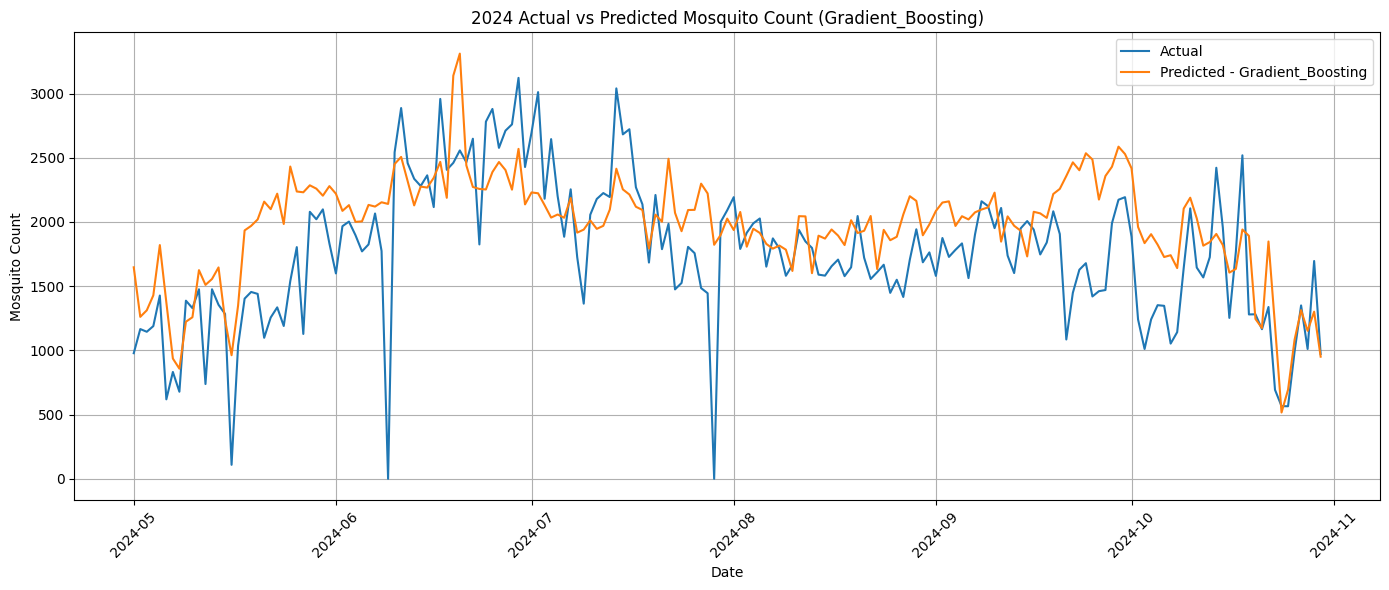

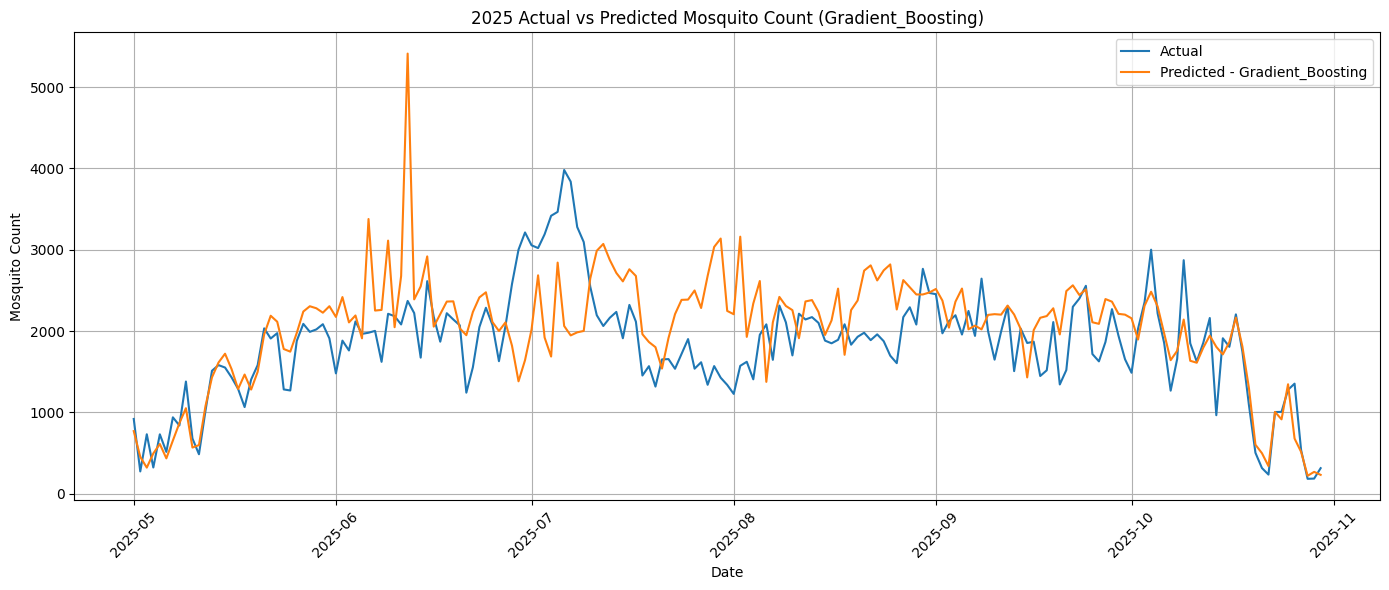

In [81]:
plt.figure(figsize=(14, 6))

plt.plot(pd.to_datetime(predictions1["date"]), predictions1["actual"], label="Actual")
plt.plot(pd.to_datetime(predictions1["date"]), predictions1[best_model_name], label=f"Predicted - {best_model_name}")

plt.title(f"2024 Actual vs Predicted Mosquito Count ({best_model_name})")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))

plt.plot(pd.to_datetime(predictions2["date"]), predictions2["actual"], label="Actual")
plt.plot(pd.to_datetime(predictions2["date"]), predictions2[best_model_name], label=f"Predicted - {best_model_name}")

plt.title(f"2025 Actual vs Predicted Mosquito Count ({best_model_name})")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

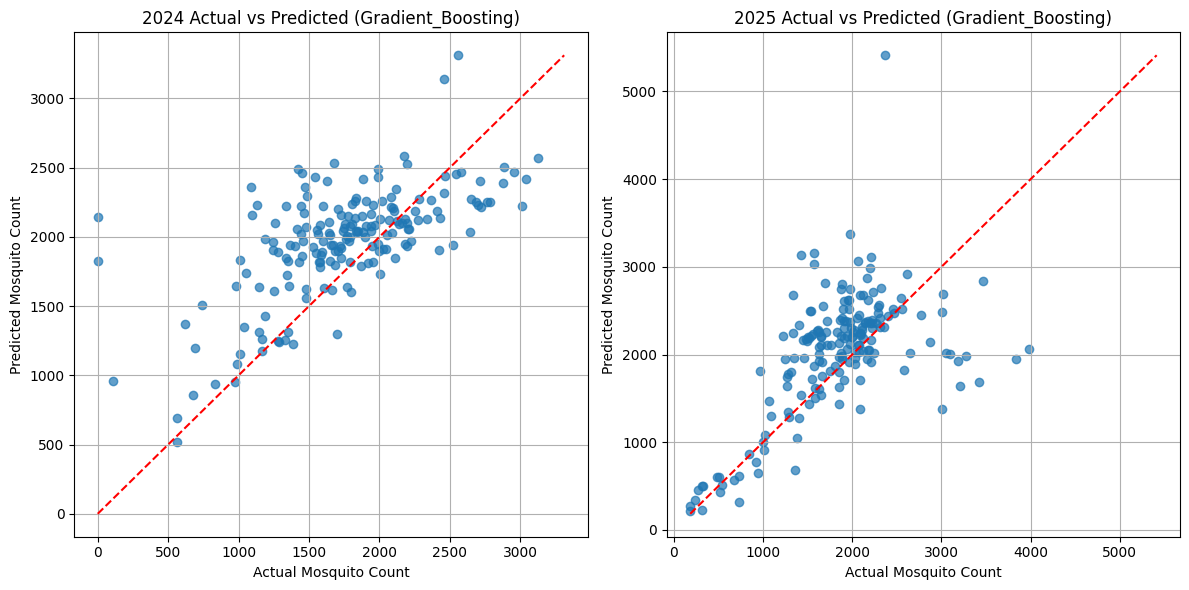

In [82]:
plt.figure(figsize=(12, 6))

# Plot for 2024 predictions
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.scatter(predictions1["actual"], predictions1[best_model_name], alpha=0.7)

min_value1 = min(predictions1["actual"].min(), predictions1[best_model_name].min())
max_value1 = max(predictions1["actual"].max(), predictions1[best_model_name].max())
plt.plot([min_value1, max_value1], [min_value1, max_value1], linestyle="--", color='red')

plt.title(f"2024 Actual vs Predicted ({best_model_name})")
plt.xlabel("Actual Mosquito Count")
plt.ylabel("Predicted Mosquito Count")
plt.grid(True)

# Plot for 2025 predictions
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.scatter(predictions2["actual"], predictions2[best_model_name], alpha=0.7)

min_value2 = min(predictions2["actual"].min(), predictions2[best_model_name].min())
max_value2 = max(predictions2["actual"].max(), predictions2[best_model_name].max())
plt.plot([min_value2, max_value2], [min_value2, max_value2], linestyle="--", color='red')

plt.title(f"2025 Actual vs Predicted ({best_model_name})")
plt.xlabel("Actual Mosquito Count")
plt.ylabel("Predicted Mosquito Count")
plt.grid(True)

plt.tight_layout()
plt.show()

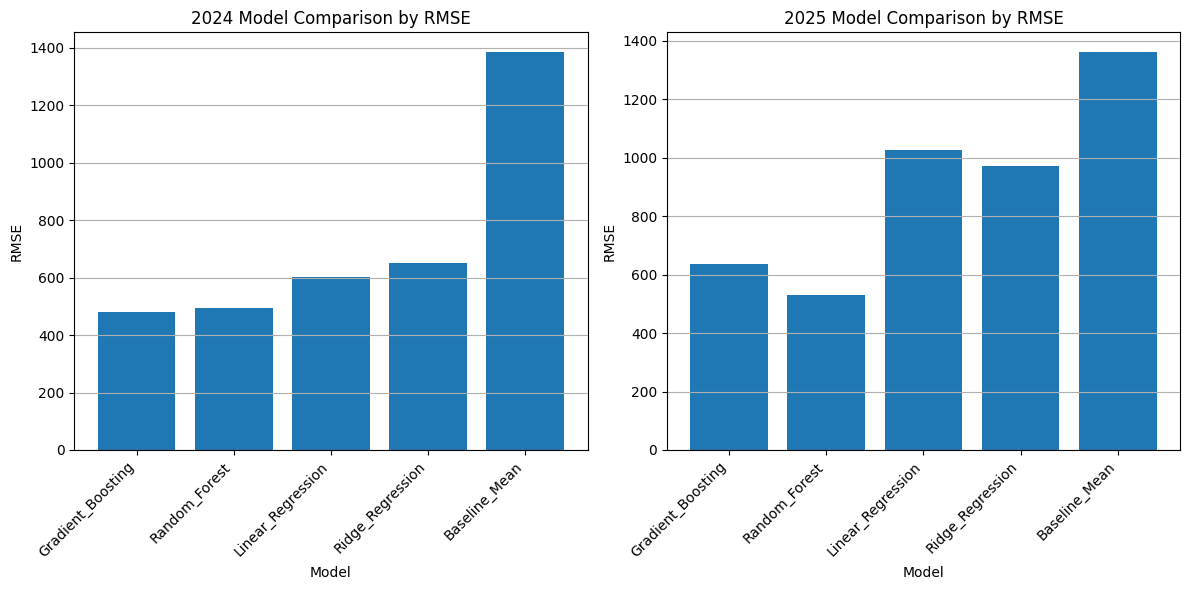

In [83]:
plt.figure(figsize=(12, 6))

# Plot for 2024 RMSE
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.bar(results_df["model"], results_df["RMSE_2024"])
plt.title("2024 Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha='right')
plt.grid(axis="y")

# Plot for 2025 RMSE
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.bar(results_df["model"], results_df["RMSE_2025"])
plt.title("2025 Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha='right')
plt.grid(axis="y")

plt.tight_layout()
plt.show()

변수 중요도 저장 완료: /content/processed/best_model_feature_importance.csv


,feature,importance
25,trap_total_outlier_flag,0.293107
24,mosquito_count_outlier_flag,0.252002
0,year,0.116850
17,soil_temp_5cm_mean,0.087567
16,ground_temp_min,0.062110
19,day_of_year,0.050445
5,temp_min,0.020518
12,humidity_max,0.019603
15,ground_temp_max,0.017609
14,ground_temp_mean,0.013379


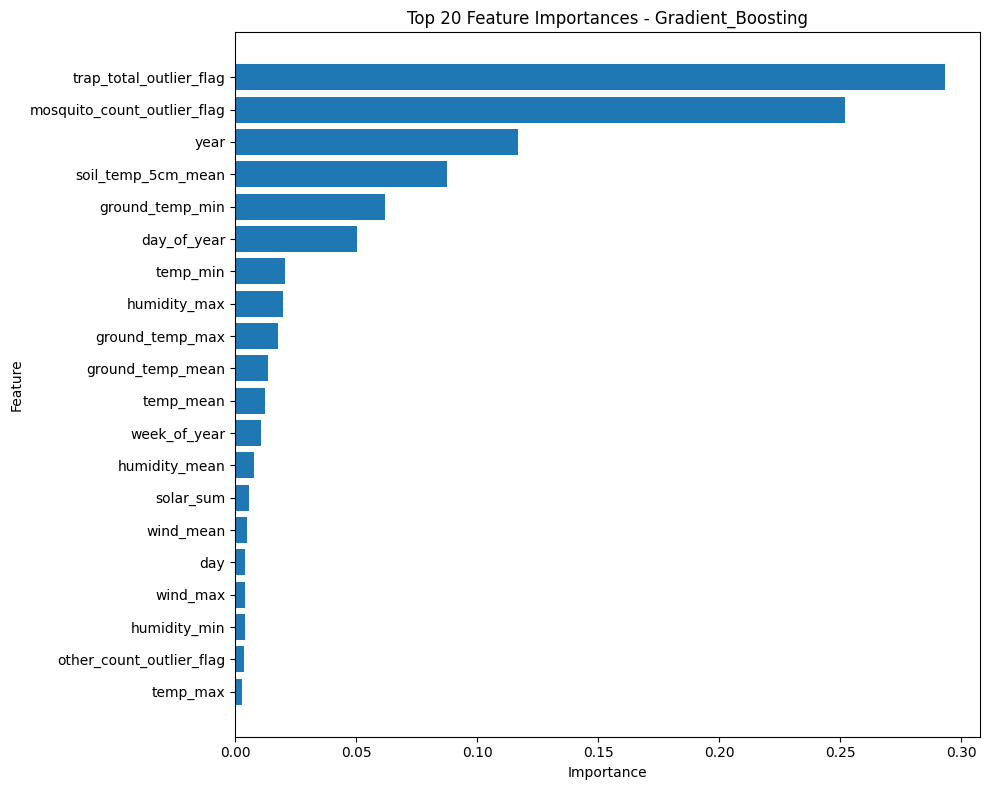

In [84]:
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False)

    importance_path = OUTPUT_DIR / "best_model_feature_importance.csv"
    importance_df.to_csv(importance_path, index=False, encoding="utf-8-sig")

    print("변수 중요도 저장 완료:", importance_path)
    display(importance_df.head(20))

    plt.figure(figsize=(10, 8))
    plt.barh(
        importance_df.head(20)["feature"][::-1],
        importance_df.head(20)["importance"][::-1]
    )
    plt.title(f"Top 20 Feature Importances - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} 모델은 feature_importances_ 속성을 제공하지 않습니다.")

###본 프로젝트에서는 DMS 모기포집량을 타깃 변수로 설정하고,
###ASOS 기상 변수와 날짜 기반 파생변수를 입력 변수로 활용하여
###2020~2023년 데이터를 학습하고 2024, 2025년 데이터를 이용해 예측 성능을 평가하였다.

###기준 모델로 평균값을 예측하는 Baseline 모델을 사용하였고,
###Linear Regression, Ridge Regression, Random Forest, Gradient Boosting 모델을 비교하였다.
###모델 성능은 MAE, RMSE, R²를 기준으로 평가하였다.

###Baseline 모델보다 낮은 MAE와 RMSE를 보이는 모델은
###단순 평균 예측보다 모기포집량을 더 잘 예측한다고 해석할 수 있다.
###또한 Random Forest 또는 Gradient Boosting 모델의 변수 중요도를 확인하여
###모기포집량 예측에 영향을 많이 준 기상 요인과 시간 요인을 분석하였다.

| 상황                                         | 해석                          |
| ------------------------------------------ | --------------------------- |
| Baseline보다 RMSE가 낮다                        | 모델이 의미 있음                   |
| R²가 0보다 크다                                 | 평균 예측보다 설명력이 있음             |
| R²가 음수다                                    | 테스트 데이터에서는 평균 예측보다 못함       |
| Random Forest/Gradient Boosting이 선형회귀보다 좋다 | 비선형 관계가 존재할 가능성             |
| 변수 중요도에서 온도·지중온도·월 변수가 높다                  | 계절성과 온도 요인이 중요함             |
| 강수량 중요도가 낮다                                | 당일 강수량보다 지연 효과 변수가 필요할 수 있음 |


#개선된 모델링 레쓰기리

In [85]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [86]:
OUTPUT_DIR = Path("/content/processed")

train_clean_path = OUTPUT_DIR / "dms_asos_train_2015_2023_clean.csv"
test1_clean_path = OUTPUT_DIR / "dms_asos_test_2024_clean.csv"
test2_clean_path = OUTPUT_DIR / "dms_asos_test_2025_clean.csv"

train_clean = pd.read_csv(train_clean_path, encoding="utf-8-sig")
test1_clean = pd.read_csv(test1_clean_path, encoding="utf-8-sig")
test2_clean = pd.read_csv(test2_clean_path, encoding="utf-8-sig")

train_clean["date"] = pd.to_datetime(train_clean["date"])
test1_clean["date"] = pd.to_datetime(test1_clean["date"])
test2_clean["date"] = pd.to_datetime(test2_clean["date"])

print("train_clean:", train_clean.shape)
print("test1_clean:", test1_clean.shape)
print("test2_clean:", test2_clean.shape)

display(train_clean.head())
display(test1_clean.head())
display(test2_clean.head())

train_clean: (1635, 48)
test1_clean: (183, 48)
test2_clean: (183, 48)


,date,year,month,day,source_year,trap_total,mosquito_count,other_count,temp_mean,temp_max,...,wind_mean_outlier_flag,wind_max_outlier_flag,humidity_mean_outlier_flag,humidity_min_outlier_flag,humidity_max_outlier_flag,solar_sum_outlier_flag,ground_temp_mean_outlier_flag,ground_temp_max_outlier_flag,ground_temp_min_outlier_flag,soil_temp_5cm_mean_outlier_flag
0,2015-05-01,2015,5,1,2015,2801.0,2783.0,18.0,20.975000,27.0,...,0,0,0,0,0,0,0,0,0,0
1,2015-05-02,2015,5,2,2015,2747.0,2729.0,18.0,20.579167,25.6,...,0,0,0,0,0,0,0,0,0,0
2,2015-05-03,2015,5,3,2015,3016.0,2998.0,18.0,18.300000,19.5,...,0,0,0,0,0,0,0,0,0,0
3,2015-05-04,2015,5,4,2015,3405.0,3392.0,13.0,16.254167,20.1,...,1,1,0,0,0,0,0,0,0,0
4,2015-05-05,2015,5,5,2015,3154.0,3137.0,17.0,14.137500,19.6,...,0,0,0,0,0,0,0,0,0,0


,date,year,month,day,source_year,trap_total,mosquito_count,other_count,temp_mean,temp_max,...,wind_mean_outlier_flag,wind_max_outlier_flag,humidity_mean_outlier_flag,humidity_min_outlier_flag,humidity_max_outlier_flag,solar_sum_outlier_flag,ground_temp_mean_outlier_flag,ground_temp_max_outlier_flag,ground_temp_min_outlier_flag,soil_temp_5cm_mean_outlier_flag
0,2024-05-01,2024,5,1,2024,991.0,978.0,13.0,18.420833,23.8,...,0,0,0,0,0,0,0,0,0,0
1,2024-05-02,2024,5,2,2024,1172.0,1166.0,6.0,18.079167,23.6,...,0,0,0,0,0,0,0,0,0,0
2,2024-05-03,2024,5,3,2024,1152.0,1145.0,7.0,19.458333,27.7,...,0,0,0,0,0,0,0,0,0,0
3,2024-05-04,2024,5,4,2024,1196.0,1189.0,7.0,21.195833,28.4,...,0,0,0,0,0,0,0,0,0,0
4,2024-05-05,2024,5,5,2024,1434.0,1427.0,7.0,18.033333,20.1,...,0,0,0,0,0,0,0,0,0,0


,date,year,month,day,source_year,trap_total,mosquito_count,other_count,temp_mean,temp_max,...,wind_mean_outlier_flag,wind_max_outlier_flag,humidity_mean_outlier_flag,humidity_min_outlier_flag,humidity_max_outlier_flag,solar_sum_outlier_flag,ground_temp_mean_outlier_flag,ground_temp_max_outlier_flag,ground_temp_min_outlier_flag,soil_temp_5cm_mean_outlier_flag
0,2025-05-01,2025,5,1,2025,934.0,920.0,14.0,14.862500,17.6,...,0,0,0,0,0,0,0,0,0,0
1,2025-05-02,2025,5,2,2025,288.0,275.0,13.0,13.212500,18.2,...,0,0,0,0,0,0,0,0,0,0
2,2025-05-03,2025,5,3,2025,747.0,732.0,15.0,11.316667,13.6,...,0,0,0,0,0,0,0,0,0,0
3,2025-05-04,2025,5,4,2025,338.0,323.0,15.0,13.566667,19.7,...,0,0,0,0,0,0,0,0,0,0
4,2025-05-05,2025,5,5,2025,741.0,731.0,10.0,12.175000,14.8,...,0,0,0,0,0,0,0,0,0,0


In [87]:
# train/test 구분 컬럼 추가
train_clean["dataset"] = "train"
test1_clean["dataset"] = "test1"
test2_clean["dataset"] = "test2"

# 전체 데이터 결합
all_data = pd.concat([train_clean, test1_clean, test2_clean], ignore_index=True)

# 날짜 기준 정렬
all_data = all_data.sort_values("date").reset_index(drop=True)

print("전체 데이터:", all_data.shape)
display(all_data.head())

전체 데이터: (2001, 49)


,date,year,month,day,source_year,trap_total,mosquito_count,other_count,temp_mean,temp_max,...,wind_max_outlier_flag,humidity_mean_outlier_flag,humidity_min_outlier_flag,humidity_max_outlier_flag,solar_sum_outlier_flag,ground_temp_mean_outlier_flag,ground_temp_max_outlier_flag,ground_temp_min_outlier_flag,soil_temp_5cm_mean_outlier_flag,dataset
0,2015-05-01,2015,5,1,2015,2801.0,2783.0,18.0,20.975000,27.0,...,0,0,0,0,0,0,0,0,0,train
1,2015-05-02,2015,5,2,2015,2747.0,2729.0,18.0,20.579167,25.6,...,0,0,0,0,0,0,0,0,0,train
2,2015-05-03,2015,5,3,2015,3016.0,2998.0,18.0,18.300000,19.5,...,0,0,0,0,0,0,0,0,0,train
3,2015-05-04,2015,5,4,2015,3405.0,3392.0,13.0,16.254167,20.1,...,1,0,0,0,0,0,0,0,0,train
4,2015-05-05,2015,5,5,2015,3154.0,3137.0,17.0,14.137500,19.6,...,0,0,0,0,0,0,0,0,0,train


In [88]:
# 파생변수를 만들 기상 변수 목록
weather_cols = [
    "temp_mean",
    "temp_max",
    "temp_min",
    "rain_sum",
    "rain_hours",
    "wind_mean",
    "wind_max",
    "humidity_mean",
    "humidity_min",
    "humidity_max",
    "solar_sum",
    "ground_temp_mean",
    "ground_temp_max",
    "ground_temp_min",
    "soil_temp_5cm_mean",
]

# 실제 존재하는 컬럼만 사용
weather_cols = [col for col in weather_cols if col in all_data.columns]

# 날짜 정렬
all_data = all_data.sort_values(["year", "date"]).reset_index(drop=True)

# 1일 전, 3일 전, 7일 전 기상 변수
lag_days = [1, 3, 7]

for col in weather_cols:
    for lag in lag_days:
        all_data[f"{col}_lag{lag}"] = all_data.groupby("year")[col].shift(lag)

# 최근 3일, 7일 rolling 변수
rolling_windows = [3, 7]

for col in weather_cols:
    for window in rolling_windows:
        if col in ["rain_sum", "rain_hours"]:
            # 강수량, 강수 시간은 최근 며칠 누적값
            all_data[f"{col}_{window}d_sum"] = (
                all_data
                .groupby("year")[col]
                .transform(lambda x: x.shift(1).rolling(window=window, min_periods=1).sum())
            )
        else:
            # 나머지 기상 변수는 최근 며칠 평균값
            all_data[f"{col}_{window}d_mean"] = (
                all_data
                .groupby("year")[col]
                .transform(lambda x: x.shift(1).rolling(window=window, min_periods=1).mean())
            )

print("lag/rolling 파생변수 생성 완료")
print("전체 데이터:", all_data.shape)

display(all_data.head())

lag/rolling 파생변수 생성 완료
전체 데이터: (2001, 124)


,date,year,month,day,source_year,trap_total,mosquito_count,other_count,temp_mean,temp_max,...,solar_sum_3d_mean,solar_sum_7d_mean,ground_temp_mean_3d_mean,ground_temp_mean_7d_mean,ground_temp_max_3d_mean,ground_temp_max_7d_mean,ground_temp_min_3d_mean,ground_temp_min_7d_mean,soil_temp_5cm_mean_3d_mean,soil_temp_5cm_mean_7d_mean
0,2015-05-01,2015,5,1,2015,2801.0,2783.0,18.0,20.975000,27.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-05-02,2015,5,2,2015,2747.0,2729.0,18.0,20.579167,25.6,...,22.130000,22.1300,24.295833,24.295833,42.200000,42.200000,13.700000,13.700000,22.430435,22.430435
2,2015-05-03,2015,5,3,2015,3016.0,2998.0,18.0,18.300000,19.5,...,18.685000,18.6850,23.758333,23.758333,39.150000,39.150000,13.950000,13.950000,20.758696,20.758696
3,2015-05-04,2015,5,4,2015,3405.0,3392.0,13.0,16.254167,20.1,...,14.210000,14.2100,22.301389,22.301389,33.466667,33.466667,14.633333,14.633333,20.321075,20.321075
4,2015-05-05,2015,5,5,2015,3154.0,3137.0,17.0,14.137500,19.6,...,14.893333,16.7025,20.838889,21.703125,30.700000,33.575000,13.333333,13.425000,19.251839,20.046488


In [89]:
USE_MOSQUITO_LAG = True

if USE_MOSQUITO_LAG:
    all_data["mosquito_count_lag1"] = all_data.groupby("year")["mosquito_count"].shift(1)
    all_data["mosquito_count_lag3"] = all_data.groupby("year")["mosquito_count"].shift(3)
    all_data["mosquito_count_lag7"] = all_data.groupby("year")["mosquito_count"].shift(7)

    all_data["mosquito_count_3d_mean"] = (
        all_data
        .groupby("year")["mosquito_count"]
        .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
    )

    all_data["mosquito_count_7d_mean"] = (
        all_data
        .groupby("year")["mosquito_count"]
        .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
    )

print("이전 모기포집량 파생변수 추가 여부:", USE_MOSQUITO_LAG)

이전 모기포집량 파생변수 추가 여부: True


In [90]:
train_fe = all_data[all_data["dataset"] == "train"].copy()
test1_fe = all_data[all_data["dataset"] == "test1"].copy()
test2_fe = all_data[all_data["dataset"] == "test2"].copy()

train_fe = train_fe.sort_values("date").reset_index(drop=True)
test1_fe = test1_fe.sort_values("date").reset_index(drop=True)
test2_fe = test2_fe.sort_values("date").reset_index(drop=True)

print("파생변수 적용 train:", train_fe.shape)
print("파생변수 적용 test1:", test1_fe.shape)
print("파생변수 적용 test2:", test2_fe.shape)

파생변수 적용 train: (1635, 129)
파생변수 적용 test1: (183, 129)
파생변수 적용 test2: (183, 129)


In [91]:
TARGET_COL = "mosquito_count"

drop_cols = [
    "date",
    "dataset",
    "source_year",
    "trap_total",
    "other_count",
    TARGET_COL
]

drop_cols = [col for col in drop_cols if col in train_fe.columns]

feature_cols = [col for col in train_fe.columns if col not in drop_cols]

X_train = train_fe[feature_cols].copy()
y_train = train_fe[TARGET_COL].copy()

X_test1 = test1_fe[feature_cols].copy()
y_test1 = test1_fe[TARGET_COL].copy()

X_test2 = test2_fe[feature_cols].copy()
y_test2 = test2_fe[TARGET_COL].copy()

print("X_train:", X_train.shape)
print("X_test1:", X_test1.shape)
print("X_test2:", X_test2.shape)
print("y_train:", y_train.shape)
print("y_test1:", y_test1.shape)
print("y_test2:", y_test2.shape)

print("\n사용 feature 개수:", len(feature_cols))
print(feature_cols)

X_train: (1635, 123)
X_test1: (183, 123)
X_test2: (183, 123)
y_train: (1635,)
y_test1: (183,)
y_test2: (183,)

사용 feature 개수: 123
['year', 'month', 'day', 'temp_mean', 'temp_max', 'temp_min', 'rain_sum', 'rain_hours', 'wind_mean', 'wind_max', 'humidity_mean', 'humidity_min', 'humidity_max', 'solar_sum', 'ground_temp_mean', 'ground_temp_max', 'ground_temp_min', 'soil_temp_5cm_mean', 'hour_count', 'day_of_year', 'week_of_year', 'day_of_week', 'season', 'month_sin', 'month_cos', 'mosquito_count_outlier_flag', 'trap_total_outlier_flag', 'other_count_outlier_flag', 'temp_mean_outlier_flag', 'temp_max_outlier_flag', 'temp_min_outlier_flag', 'rain_sum_outlier_flag', 'rain_hours_outlier_flag', 'wind_mean_outlier_flag', 'wind_max_outlier_flag', 'humidity_mean_outlier_flag', 'humidity_min_outlier_flag', 'humidity_max_outlier_flag', 'solar_sum_outlier_flag', 'ground_temp_mean_outlier_flag', 'ground_temp_max_outlier_flag', 'ground_temp_min_outlier_flag', 'soil_temp_5cm_mean_outlier_flag', 'temp_me

In [92]:
categorical_cols = [
    col for col in feature_cols
    if X_train[col].dtype == "object"
]

numeric_cols = [
    col for col in feature_cols
    if col not in categorical_cols
]

print("수치형 변수 개수:", len(numeric_cols))
print("범주형 변수 개수:", len(categorical_cols))

print("\n범주형 변수:")
print(categorical_cols)

수치형 변수 개수: 122
범주형 변수 개수: 1

범주형 변수:
['season']


In [93]:
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ],
    remainder="drop"
)

# train 기준으로만 fit
X_train_processed = preprocessor.fit_transform(X_train)

# 테스트는 transform만
X_test1_processed = preprocessor.transform(X_test1)
X_test2_processed = preprocessor.transform(X_test2)

print("X_train_processed:", X_train_processed.shape)
print("X_test1_processed:", X_test1_processed.shape)
print("X_test2_processed:", X_test2_processed.shape)

X_train_processed: (1635, 125)
X_test1_processed: (183, 125)
X_test2_processed: (183, 125)


In [94]:
models = {
    "Baseline_Mean": DummyRegressor(strategy="mean"),
    "Linear_Regression": LinearRegression(),
    "Ridge_Regression": Ridge(alpha=1.0),
    "Random_Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        n_jobs=-1
    ),
    "Gradient_Boosting": GradientBoostingRegressor(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3
    )
}

In [95]:
results = []

predictions1 = pd.DataFrame({
    "date": test1_fe["date"],
    "actual": y_test1
})

predictions2 = pd.DataFrame({
    "date": test2_fe["date"],
    "actual": y_test2
})

trained_models = {}

for model_name, model in models.items():
    print(f"\n===== {model_name} 학습 중 =====")

    model.fit(X_train_processed, y_train)

    # 예측1 (2024)
    y_pred1 = model.predict(X_test1_processed)

    # 예측2 (2025)
    y_pred2 = model.predict(X_test2_processed)

    # 평가 지표1 (2024)
    mae1 = mean_absolute_error(y_test1, y_pred1)
    rmse1 = np.sqrt(mean_squared_error(y_test1, y_pred1))
    r2_1 = r2_score(y_test1, y_pred1)

    # 평가 지표2 (2025)
    mae2 = mean_absolute_error(y_test2, y_pred2)
    rmse2 = np.sqrt(mean_squared_error(y_test2, y_pred2))
    r2_2 = r2_score(y_test2, y_pred2)

    results.append({
        "model": model_name,
        "MAE_2024": mae1,
        "RMSE_2024": rmse1,
        "R2_2024": r2_1,
        "MAE_2025": mae2,
        "RMSE_2025": rmse2,
        "R2_2025": r2_2
    })

    predictions1[model_name] = y_pred1
    predictions2[model_name] = y_pred2
    trained_models[model_name] = model

    print(f"MAE (2024): {round(mae1, 3)}")
    print(f"RMSE (2024): {round(rmse1, 3)}")
    print(f"R2 (2024): {round(r2_1, 3)}")
    print(f"MAE (2025): {round(mae2, 3)}")
    print(f"RMSE (2025): {round(rmse2, 3)}")
    print(f"R2 (2025): {round(r2_2, 3)}")

# Sorting by 2024 RMSE for consistency
results_df = pd.DataFrame(results).sort_values("RMSE_2024")

print("\n개선 모델 성능 비교")
display(results_df)


===== Baseline_Mean 학습 중 =====
MAE (2024): 1269.153
RMSE (2024): 1385.285
R2 (2024): -5.158
MAE (2025): 1226.437
RMSE (2025): 1361.201
R2 (2025): -3.238

===== Linear_Regression 학습 중 =====
MAE (2024): 349.798
RMSE (2024): 454.476
R2 (2024): 0.337
MAE (2025): 519.003
RMSE (2025): 631.156
R2 (2025): 0.089

===== Ridge_Regression 학습 중 =====
MAE (2024): 352.224
RMSE (2024): 456.321
R2 (2024): 0.332
MAE (2025): 512.204
RMSE (2025): 621.55
R2 (2025): 0.116

===== Random_Forest 학습 중 =====
MAE (2024): 250.174
RMSE (2024): 364.908
R2 (2024): 0.573
MAE (2025): 247.868
RMSE (2025): 313.182
R2 (2025): 0.776

===== Gradient_Boosting 학습 중 =====
MAE (2024): 240.457
RMSE (2024): 359.529
R2 (2024): 0.585
MAE (2025): 294.979
RMSE (2025): 369.429
R2 (2025): 0.688

개선 모델 성능 비교


,model,MAE_2024,RMSE_2024,R2_2024,MAE_2025,RMSE_2025,R2_2025
4,Gradient_Boosting,240.457162,359.529361,0.585181,294.978906,369.428689,0.687827
3,Random_Forest,250.174499,364.908160,0.572676,247.867541,313.182434,0.775649
1,Linear_Regression,349.798213,454.475769,0.337156,519.003354,631.155805,0.088814
2,Ridge_Regression,352.223564,456.321461,0.331762,512.204022,621.549914,0.116339
0,Baseline_Mean,1269.153229,1385.285141,-5.158402,1226.436904,1361.200738,-3.238167


In [96]:
metrics_path = OUTPUT_DIR / "model_metrics_lag_rolling.csv"
predictions1_path = OUTPUT_DIR / "model_predictions_2024_lag_rolling.csv"
predictions2_path = OUTPUT_DIR / "model_predictions_2025_lag_rolling.csv"

results_df.to_csv(metrics_path, index=False, encoding="utf-8-sig")
predictions1.to_csv(predictions1_path, index=False, encoding="utf-8-sig")
predictions2.to_csv(predictions2_path, index=False, encoding="utf-8-sig")

print("개선 모델 성능 저장 완료:", metrics_path)
print("2024년 예측 결과 저장 완료:", predictions1_path)
print("2025년 예측 결과 저장 완료:", predictions2_path)

개선 모델 성능 저장 완료: /content/processed/model_metrics_lag_rolling.csv
2024년 예측 결과 저장 완료: /content/processed/model_predictions_2024_lag_rolling.csv
2025년 예측 결과 저장 완료: /content/processed/model_predictions_2025_lag_rolling.csv


In [97]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("가장 성능이 좋은 개선 모델:", best_model_name)

가장 성능이 좋은 개선 모델: Gradient_Boosting


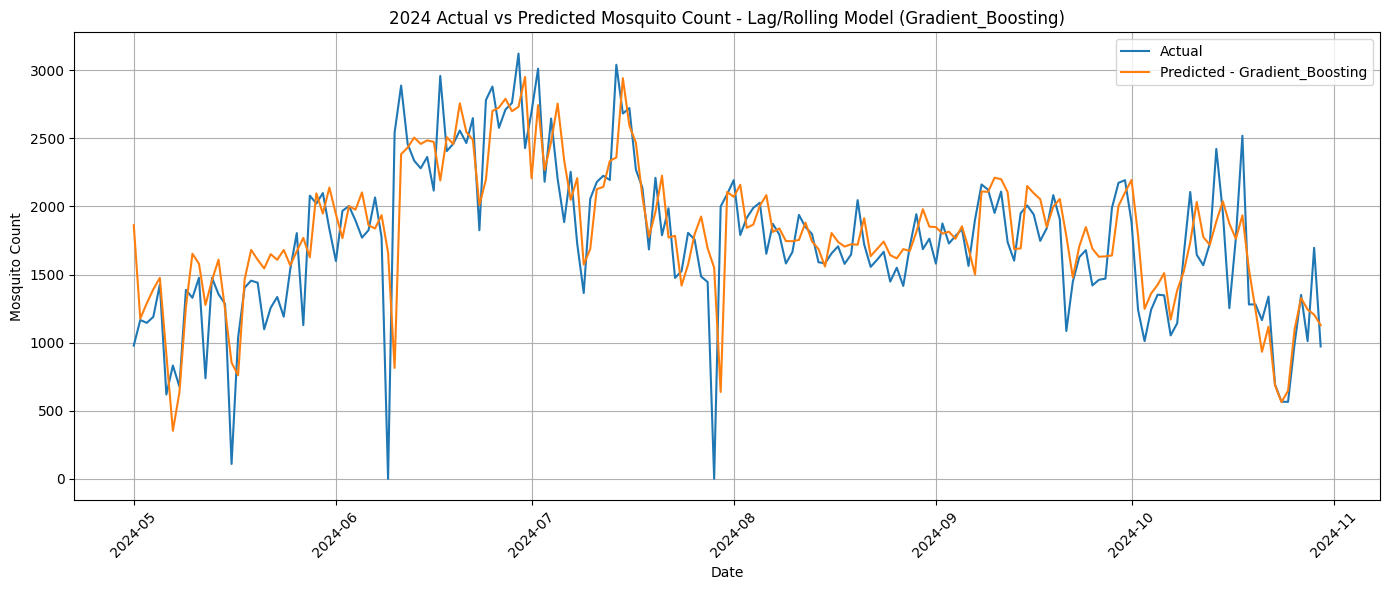

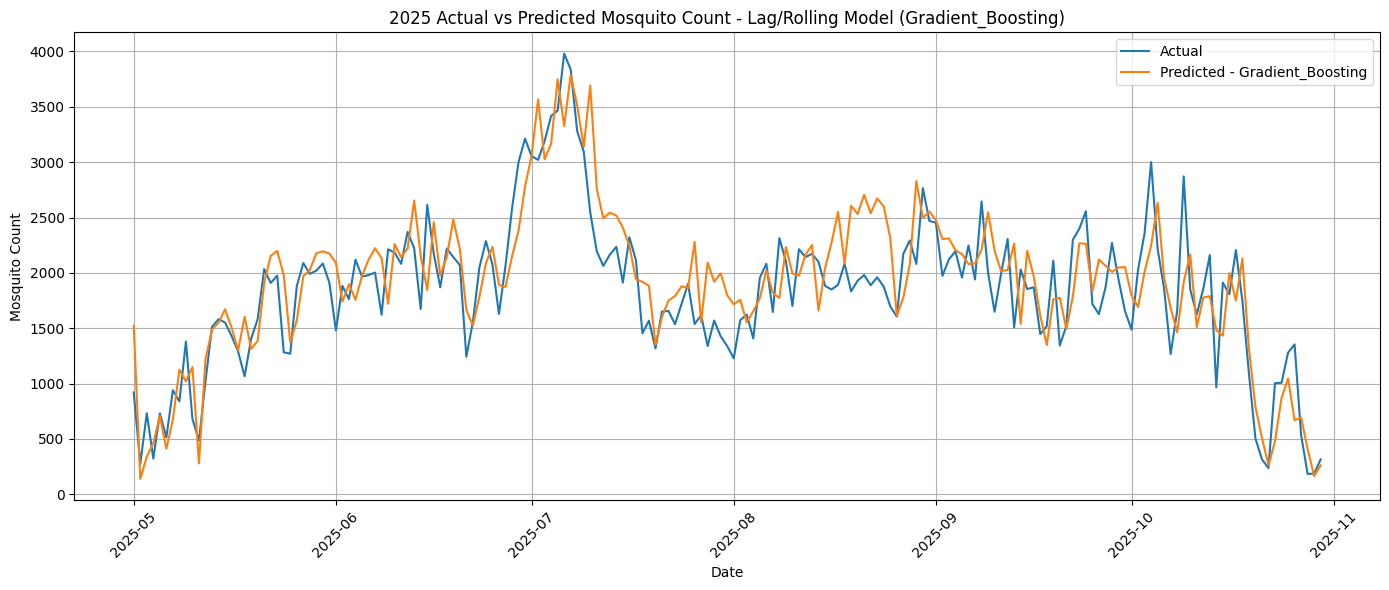

In [98]:
plt.figure(figsize=(14, 6))

plt.plot(
    pd.to_datetime(predictions1["date"]),
    predictions1["actual"],
    label="Actual"
)

plt.plot(
    pd.to_datetime(predictions1["date"]),
    predictions1[best_model_name],
    label=f"Predicted - {best_model_name}"
)

plt.title(f"2024 Actual vs Predicted Mosquito Count - Lag/Rolling Model ({best_model_name})")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))

plt.plot(
    pd.to_datetime(predictions2["date"]),
    predictions2["actual"],
    label="Actual"
)

plt.plot(
    pd.to_datetime(predictions2["date"]),
    predictions2[best_model_name],
    label=f"Predicted - {best_model_name}"
)

plt.title(f"2025 Actual vs Predicted Mosquito Count - Lag/Rolling Model ({best_model_name})")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

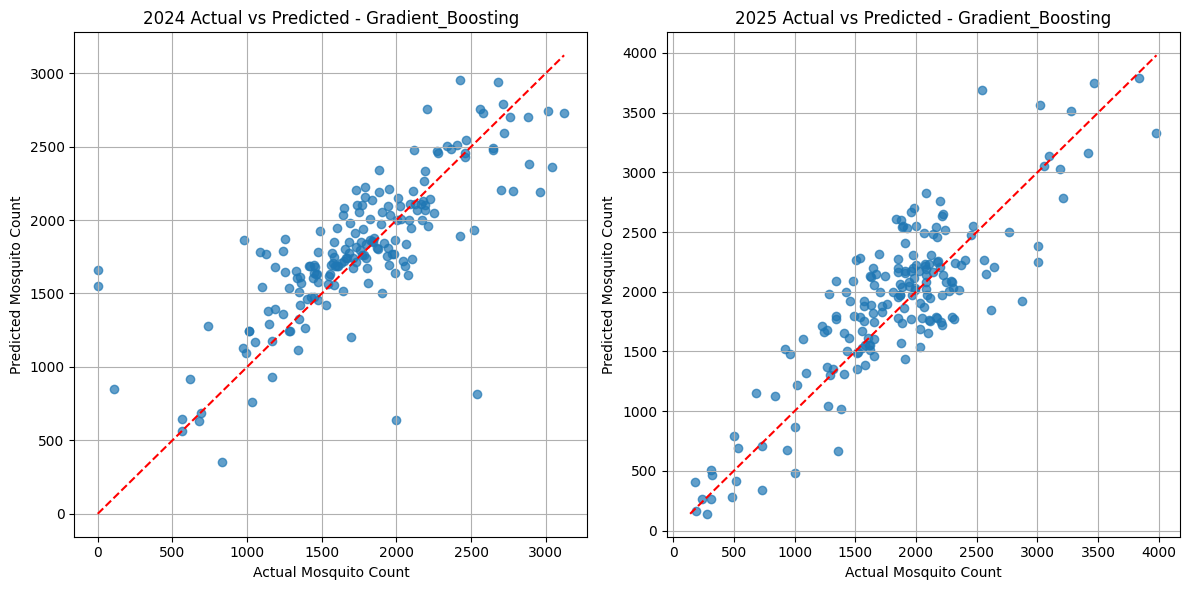

In [99]:
plt.figure(figsize=(12, 6))

# Plot for 2024 predictions
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.scatter(predictions1["actual"], predictions1[best_model_name], alpha=0.7)

min_value1 = min(predictions1["actual"].min(), predictions1[best_model_name].min())
max_value1 = max(predictions1["actual"].max(), predictions1[best_model_name].max())
plt.plot([min_value1, max_value1], [min_value1, max_value1], linestyle="--", color='red')

plt.title(f"2024 Actual vs Predicted - {best_model_name}")
plt.xlabel("Actual Mosquito Count")
plt.ylabel("Predicted Mosquito Count")
plt.grid(True)

# Plot for 2025 predictions
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.scatter(predictions2["actual"], predictions2[best_model_name], alpha=0.7)

min_value2 = min(predictions2["actual"].min(), predictions2[best_model_name].min())
max_value2 = max(predictions2["actual"].max(), predictions2[best_model_name].max())
plt.plot([min_value2, max_value2], [min_value2, max_value2], linestyle="--", color='red')

plt.title(f"2025 Actual vs Predicted - {best_model_name}")
plt.xlabel("Actual Mosquito Count")
plt.ylabel("Predicted Mosquito Count")
plt.grid(True)

plt.tight_layout()
plt.show()

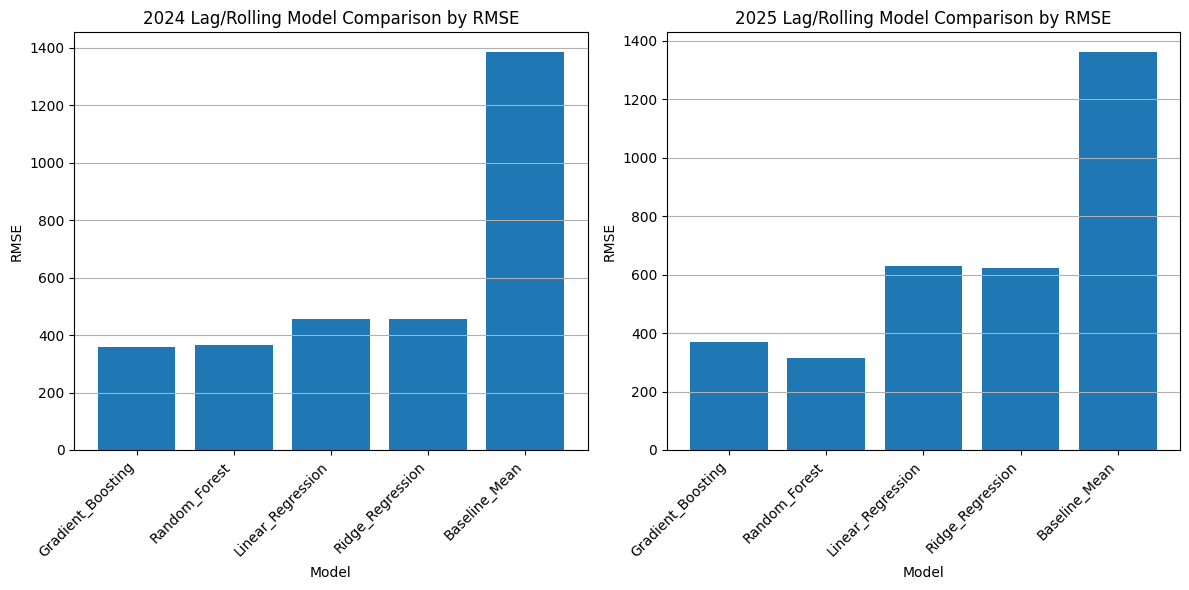

In [100]:
plt.figure(figsize=(12, 6))

# Plot for 2024 RMSE
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.bar(results_df["model"], results_df["RMSE_2024"])
plt.title("2024 Lag/Rolling Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha='right')
plt.grid(axis="y")

# Plot for 2025 RMSE
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.bar(results_df["model"], results_df["RMSE_2025"])
plt.title("2025 Lag/Rolling Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha='right')
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [101]:
# 범주형 one-hot 변수명 가져오기
if len(categorical_cols) > 0:
    cat_encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    encoded_cat_names = cat_encoder.get_feature_names_out(categorical_cols).tolist()
else:
    encoded_cat_names = []

final_feature_names = numeric_cols + encoded_cat_names

print("최종 feature 개수:", len(final_feature_names))

최종 feature 개수: 125


변수 중요도 저장 완료: /content/processed/best_model_feature_importance_lag_rolling.csv


,feature,importance
25,trap_total_outlier_flag,0.259740
117,mosquito_count_lag1,0.214602
24,mosquito_count_outlier_flag,0.189093
120,mosquito_count_3d_mean,0.145167
113,ground_temp_min_3d_mean,0.017901
5,temp_min,0.013424
88,temp_mean_7d_mean,0.012878
121,mosquito_count_7d_mean,0.011531
111,ground_temp_max_3d_mean,0.009796
45,temp_max_lag1,0.009363


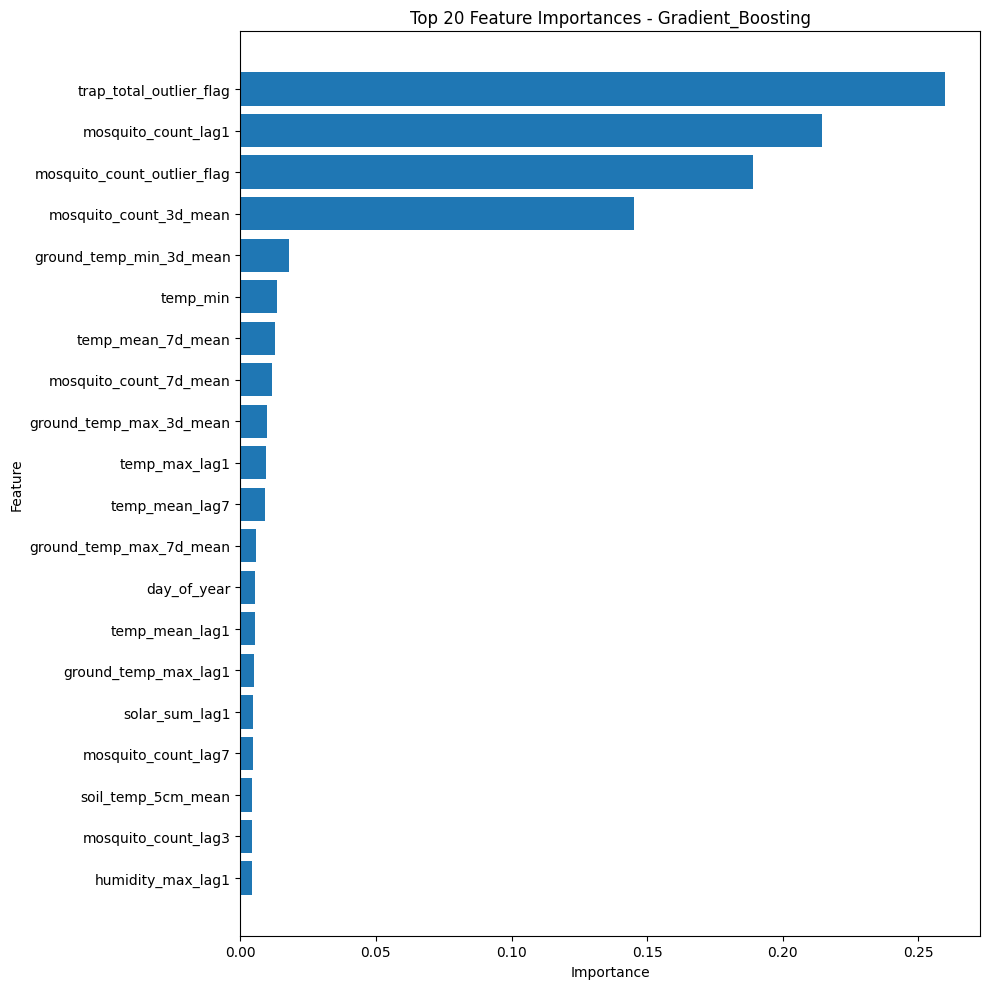

In [102]:
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": final_feature_names,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False)

    importance_path = OUTPUT_DIR / "best_model_feature_importance_lag_rolling.csv"
    importance_df.to_csv(importance_path, index=False, encoding="utf-8-sig")

    print("변수 중요도 저장 완료:", importance_path)
    display(importance_df.head(30))

    plt.figure(figsize=(10, 10))
    plt.barh(
        importance_df.head(20)["feature"][::-1],
        importance_df.head(20)["importance"][::-1]
    )
    plt.title(f"Top 20 Feature Importances - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} 모델은 feature_importances_ 속성을 제공하지 않습니다.")

In [103]:
basic_metrics_path = OUTPUT_DIR / "model_metrics.csv"
lag_metrics_path = OUTPUT_DIR / "model_metrics_lag_rolling.csv"

if basic_metrics_path.exists():
    basic_metrics = pd.read_csv(basic_metrics_path, encoding="utf-8-sig")
    lag_metrics = pd.read_csv(lag_metrics_path, encoding="utf-8-sig")

    basic_metrics["version"] = "basic"
    lag_metrics["version"] = "lag_rolling"

    # Split lag_metrics into 2024 and 2025 specific metrics for comparison
    lag_metrics_2024 = lag_metrics[['model', 'MAE_2024', 'RMSE_2024', 'R2_2024']].rename(columns={
        'MAE_2024': 'MAE', 'RMSE_2024': 'RMSE', 'R2_2024': 'R2'
    })
    lag_metrics_2024['version'] = 'lag_rolling_2024'

    lag_metrics_2025 = lag_metrics[['model', 'MAE_2025', 'RMSE_2025', 'R2_2025']].rename(columns={
        'MAE_2025': 'MAE', 'RMSE_2025': 'RMSE', 'R2_2025': 'R2'
    })
    lag_metrics_2025['version'] = 'lag_rolling_2025'

    # Split basic_metrics into 2024 and 2025 specific metrics for comparison
    basic_metrics_2024 = basic_metrics[['model', 'MAE_2024', 'RMSE_2024', 'R2_2024']].rename(columns={
        'MAE_2024': 'MAE', 'RMSE_2024': 'RMSE', 'R2_2024': 'R2'
    })
    basic_metrics_2024['version'] = 'basic_2024'

    basic_metrics_2025 = basic_metrics[['model', 'MAE_2025', 'RMSE_2025', 'R2_2025']].rename(columns={
        'MAE_2025': 'MAE', 'RMSE_2025': 'RMSE', 'R2_2025': 'R2'
    })
    basic_metrics_2025['version'] = 'basic_2025'

    # Concatenate all specific metrics for comparison
    compare_metrics = pd.concat([basic_metrics_2024, basic_metrics_2025, lag_metrics_2024, lag_metrics_2025], ignore_index=True)

    compare_path = OUTPUT_DIR / "model_metrics_comparison_basic_vs_lag.csv"
    compare_metrics.to_csv(compare_path, index=False, encoding="utf-8-sig")

    print("기본 모델 vs 개선 모델 비교 저장 완료:", compare_path)
    display(compare_metrics.sort_values(["RMSE", "version"])) # Sort by RMSE and then version for clarity
else:
    print("기본 모델 결과 파일 model_metrics.csv가 없습니다. 개선 모델 결과만 확인하세요.")

기본 모델 vs 개선 모델 비교 저장 완료: /content/processed/model_metrics_comparison_basic_vs_lag.csv


,model,MAE,RMSE,R2,version
16,Random_Forest,247.867541,313.182434,0.775649,lag_rolling_2025
10,Gradient_Boosting,240.457162,359.529361,0.585181,lag_rolling_2024
11,Random_Forest,250.174499,364.908160,0.572676,lag_rolling_2024
15,Gradient_Boosting,294.978906,369.428689,0.687827,lag_rolling_2025
12,Linear_Regression,349.798213,454.475769,0.337156,lag_rolling_2024
13,Ridge_Regression,352.223564,456.321461,0.331762,lag_rolling_2024
0,Gradient_Boosting,365.062888,481.189483,0.256943,basic_2024
1,Random_Forest,377.391913,493.709265,0.217774,basic_2024
6,Random_Forest,372.862295,528.618055,0.360828,basic_2025
2,Linear_Regression,461.102187,601.353958,-0.160513,basic_2024
